# Sprint 8

# Análise de Negócios da Y.Afisha

## Introdução

Neste projeto será realizada uma análise dos dados da plataforma Y.Afisha com o objetivo de avaliar a eficiência das estratégias de marketing utilizadas pela empresa.

A análise utilizará dados de visitas ao site, pedidos realizados pelos usuários e despesas com marketing entre janeiro de 2017 e dezembro de 2018.

Ao longo do projeto serão respondidas as seguintes questões:

- Como os usuários utilizam o produto;
- Quando os usuários realizam sua primeira compra;
- Quanto cada cliente gera de receita para a empresa (LTV);
- Quanto custa adquirir clientes (CAC);
- Se os investimentos em marketing geram retorno positivo (ROI/ROMI).

Ao final, serão apresentadas recomendações para otimizar os investimentos em marketing com base nas métricas obtidas.

# 1. Preparação dos Dados

Nesta etapa serão carregados os três conjuntos de dados utilizados na análise:

- **Visits:** informações sobre as visitas dos usuários ao site;
- **Orders:** histórico de pedidos realizados;
- **Costs:** despesas com marketing por origem de aquisição.

Também serão realizados os primeiros procedimentos de preparação dos dados, incluindo:

- conversão das colunas de data para o formato adequado;
- otimização dos tipos de dados para reduzir o consumo de memória;
- inspeção inicial da estrutura dos conjuntos de dados.

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Carregamento dos dados

visits = pd.read_csv(
    '/datasets/visits_log_us.csv',
    dtype={'Device': 'category'},
    parse_dates=['Start Ts', 'End Ts']
)

orders = pd.read_csv(
    '/datasets/orders_log_us.csv',
    parse_dates=['Buy Ts']
)

costs = pd.read_csv(
    '/datasets/costs_us.csv',
    parse_dates=['dt']
)

## 1.1 Inspeção inicial dos dados

Após o carregamento dos conjuntos de dados, será realizada uma inspeção inicial para verificar sua estrutura.

Serão analisados:

- as primeiras linhas de cada conjunto de dados;
- o número de registros e colunas;
- os tipos de dados;
- o consumo de memória.

Essa etapa garante que os dados foram importados corretamente antes do início da análise.

In [41]:
# Primeiras linhas dos datasets

print('VISITS')
display(visits.head())

print('ORDERS')
display(orders.head())

print('COSTS')
display(costs.head())

VISITS


,Device,End Ts,Source Id,Start Ts,Uid
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168


ORDERS


,Buy Ts,Revenue,Uid
0,2017-06-01 00:10:00,17.00,10329302124590727494
1,2017-06-01 00:25:00,0.55,11627257723692907447
2,2017-06-01 00:27:00,0.37,17903680561304213844
3,2017-06-01 00:29:00,0.55,16109239769442553005
4,2017-06-01 07:58:00,0.37,14200605875248379450


COSTS


,source_id,dt,costs
0,1,2017-06-01,75.20
1,1,2017-06-02,62.25
2,1,2017-06-03,36.53
3,1,2017-06-04,55.00
4,1,2017-06-05,57.08


## 1.2 Estrutura dos conjuntos de dados

Após verificar as primeiras linhas dos arquivos, será analisada a estrutura de cada conjunto de dados.

Nesta etapa serão verificados:

- quantidade de registros;
- quantidade de colunas;
- tipos de dados;
- valores ausentes;
- consumo de memória.

Essa verificação permite identificar possíveis problemas antes do início da análise.

In [42]:
print('VISITS')
visits.info(memory_usage='deep')

print('\n' + '='*60 + '\n')

print('ORDERS')
orders.info(memory_usage='deep')

print('\n' + '='*60 + '\n')

print('COSTS')
costs.info(memory_usage='deep')

VISITS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   Device     359400 non-null  category      
 1   End Ts     359400 non-null  datetime64[ns]
 2   Source Id  359400 non-null  int64         
 3   Start Ts   359400 non-null  datetime64[ns]
 4   Uid        359400 non-null  uint64        
dtypes: category(1), datetime64[ns](2), int64(1), uint64(1)
memory usage: 11.3 MB


ORDERS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Buy Ts   50415 non-null  datetime64[ns]
 1   Revenue  50415 non-null  float64       
 2   Uid      50415 non-null  uint64        
dtypes: datetime64[ns](1), float64(1), uint64(1)
memory usage: 1.2 MB


COSTS
<class 'pandas.core.frame.DataFrame'>
RangeIn

## 1.3 Verificação da qualidade dos dados

Antes de iniciar a análise, serão verificadas possíveis inconsistências nos conjuntos de dados.

Nesta etapa serão analisados:

- registros duplicados;
- período coberto pelos dados.

Essas verificações garantem que a análise será realizada sobre dados consistentes.

In [43]:
# Verificando registros duplicados

print('Duplicados em visits:', visits.duplicated().sum())
print('Duplicados em orders:', orders.duplicated().sum())
print('Duplicados em costs:', costs.duplicated().sum())

print('\n' + '='*60 + '\n')

# Verificando o período dos dados

print('VISITS')
print(visits['Start Ts'].min(), '-', visits['Start Ts'].max())

print('\nORDERS')
print(orders['Buy Ts'].min(), '-', orders['Buy Ts'].max())

print('\nCOSTS')
print(costs['dt'].min(), '-', costs['dt'].max())

Duplicados em visits: 0
Duplicados em orders: 0
Duplicados em costs: 0


VISITS
2017-06-01 00:01:00 - 2018-05-31 23:59:00

ORDERS
2017-06-01 00:10:00 - 2018-06-01 00:02:00

COSTS
2017-06-01 00:00:00 - 2018-05-31 00:00:00


### Conclusões da preparação dos dados

Após a inspeção inicial dos conjuntos de dados, foi possível verificar que:

- Não existem valores ausentes em nenhuma das tabelas.
- Não foram encontrados registros duplicados.
- As colunas de data foram convertidas corretamente para o tipo `datetime`.
- A coluna `Device` foi otimizada para o tipo `category`, reduzindo o consumo de memória.
- Os dados de visitas e custos abrangem o período de junho de 2017 a maio de 2018, enquanto os pedidos se estendem até o início de junho de 2018, indicando que algumas compras podem ter ocorrido após a última visita registrada.

Assim, os dados estão consistentes e prontos para a etapa de análise.

# 2. Análise do Produto

Nesta seção analisaremos como os usuários utilizam a plataforma Y.Afisha ao longo do tempo.

Os principais indicadores avaliados serão:

- Daily Active Users (DAU)
- Weekly Active Users (WAU)
- Monthly Active Users (MAU)
- Número de sessões
- Duração das sessões
- Frequência de retorno dos usuários

Essas métricas ajudam a compreender o nível de engajamento do produto e servem como base para as análises de vendas e marketing desenvolvidas nas próximas etapas.

## 2.1 Usuários Ativos (DAU, WAU e MAU)

Os primeiros indicadores analisados são os usuários ativos ao longo do tempo.

Foram calculadas três métricas fundamentais:

- DAU (Daily Active Users): número de usuários ativos por dia;
- WAU (Weekly Active Users): número de usuários ativos por semana;
- MAU (Monthly Active Users): número de usuários ativos por mês.

Esses indicadores permitem avaliar o crescimento da base de usuários e identificar possíveis padrões de utilização ao longo do período analisado.

In [44]:
# ============================================================
# 2.1 Usuários Ativos (DAU, WAU e MAU)
# ============================================================

# Criando colunas auxiliares
visits['session_date'] = visits['Start Ts'].dt.date
visits['session_week'] = visits['Start Ts'].dt.isocalendar().week.astype('int64')
visits['session_month'] = visits['Start Ts'].dt.to_period('M')

# Daily Active Users
dau = visits.groupby('session_date')['Uid'].nunique()

# Weekly Active Users
wau = visits.groupby('session_week')['Uid'].nunique()

# Monthly Active Users
mau = visits.groupby('session_month')['Uid'].nunique()

print(f'DAU médio: {dau.mean():.0f}')
print(f'WAU médio: {wau.mean():.0f}')
print(f'MAU médio: {mau.mean():.0f}')

DAU médio: 908
WAU médio: 5825
MAU médio: 23228


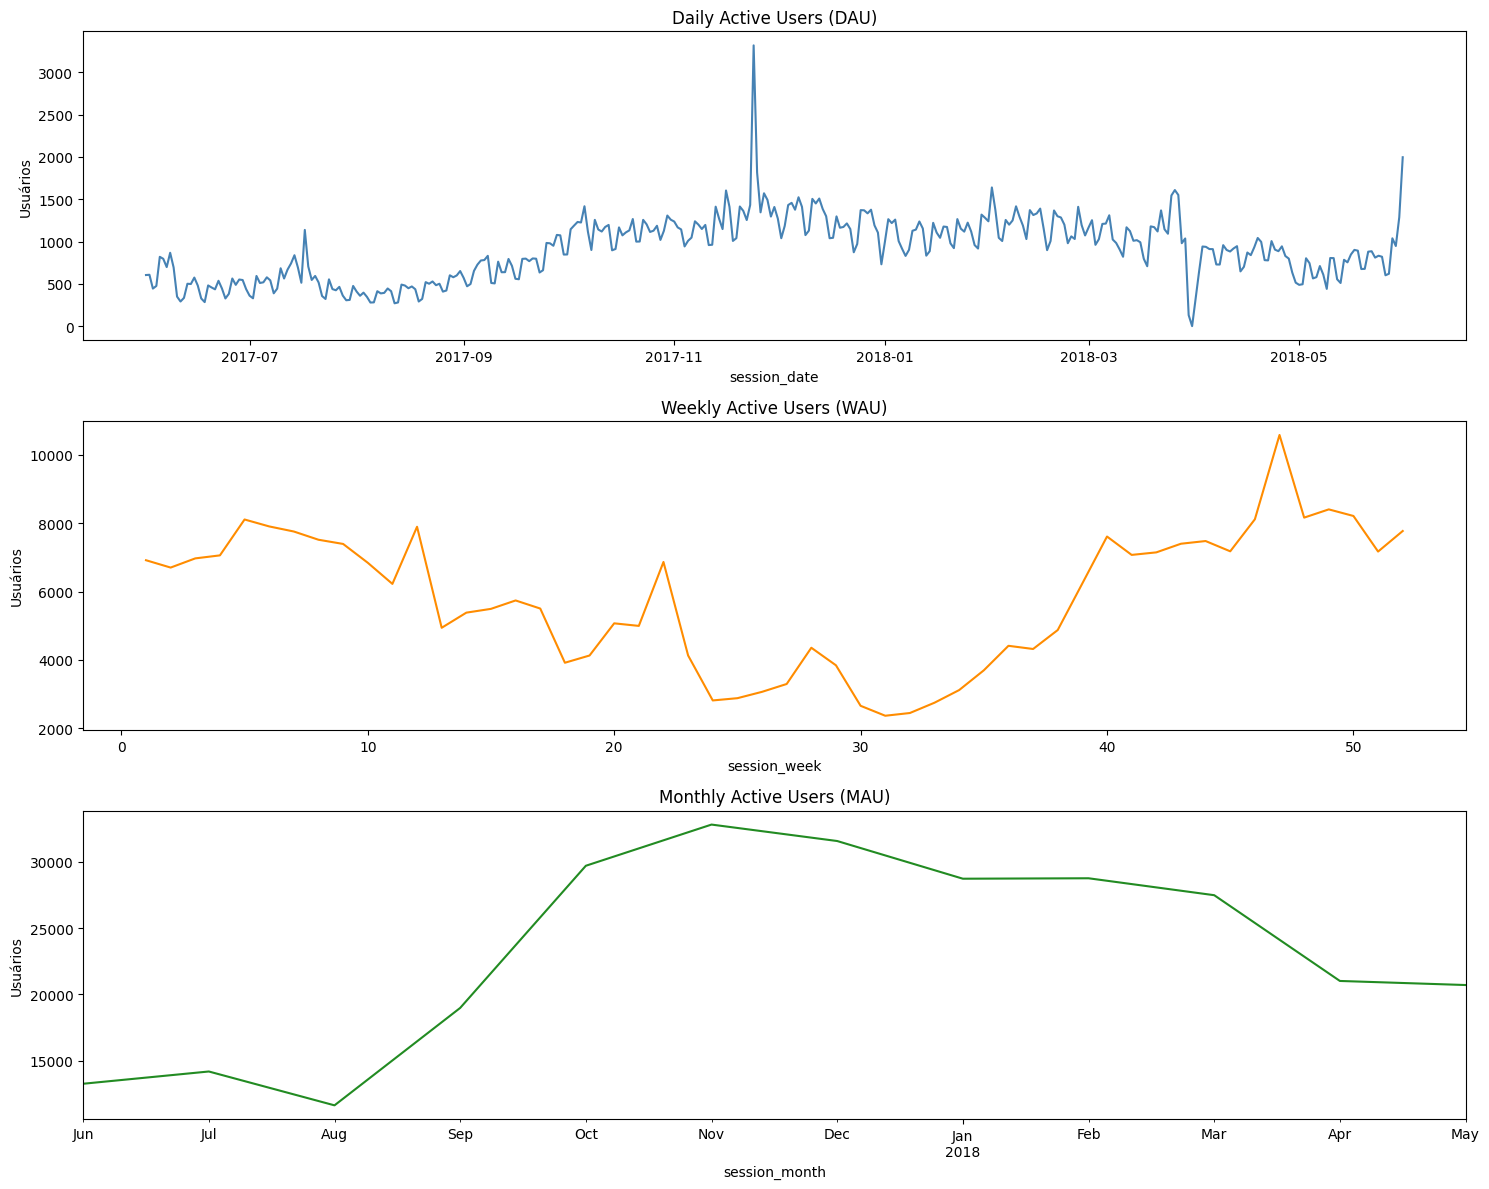

In [45]:
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

# DAU
dau.plot(ax=axes[0], color='steelblue')
axes[0].set_title('Daily Active Users (DAU)')
axes[0].set_ylabel('Usuários')

# WAU
wau.plot(ax=axes[1], color='darkorange')
axes[1].set_title('Weekly Active Users (WAU)')
axes[1].set_ylabel('Usuários')

# MAU
mau.plot(ax=axes[2], color='forestgreen')
axes[2].set_title('Monthly Active Users (MAU)')
axes[2].set_ylabel('Usuários')

plt.tight_layout()
plt.show()

### Conclusão

Os indicadores DAU, WAU e MAU mostram que a plataforma manteve uma base consistente de usuários ativos durante o período analisado.

Embora existam oscilações naturais ao longo do tempo, observa-se um comportamento relativamente estável, sem sinais de perda contínua de usuários. Alguns picos de atividade merecem investigação posterior, pois podem estar relacionados a campanhas de marketing, sazonalidade ou eventos específicos.

Essas métricas servirão como base para avaliar se o aumento de usuários ativos resulta, de fato, em crescimento das vendas e melhor retorno sobre os investimentos em marketing.

## 2.2 Sessões

Após entender o comportamento da base de usuários, o próximo passo é analisar como esses usuários utilizam a plataforma.

Nesta etapa serão avaliados:

- Quantidade de sessões realizadas;
- Duração das sessões;
- Frequência de retorno dos usuários.

Essas métricas ajudam a compreender o nível de engajamento dos usuários e a intensidade de utilização do serviço.

### 2.2.1 Número de sessões por dia

In [46]:
# Calculando o número de sessões por dia
sessions_per_day = (
    visits
    .groupby('session_date')
    .size()
)

# Média diária de sessões
avg_sessions = sessions_per_day.mean()

print(f'Média de sessões por dia: {avg_sessions:.0f}')

print('\nEstatísticas descritivas:')
print(sessions_per_day.describe())

Média de sessões por dia: 987

Estatísticas descritivas:
count     364.000000
mean      987.362637
std       418.994796
min         1.000000
25%       635.500000
50%      1003.000000
75%      1280.000000
max      4042.000000
dtype: float64


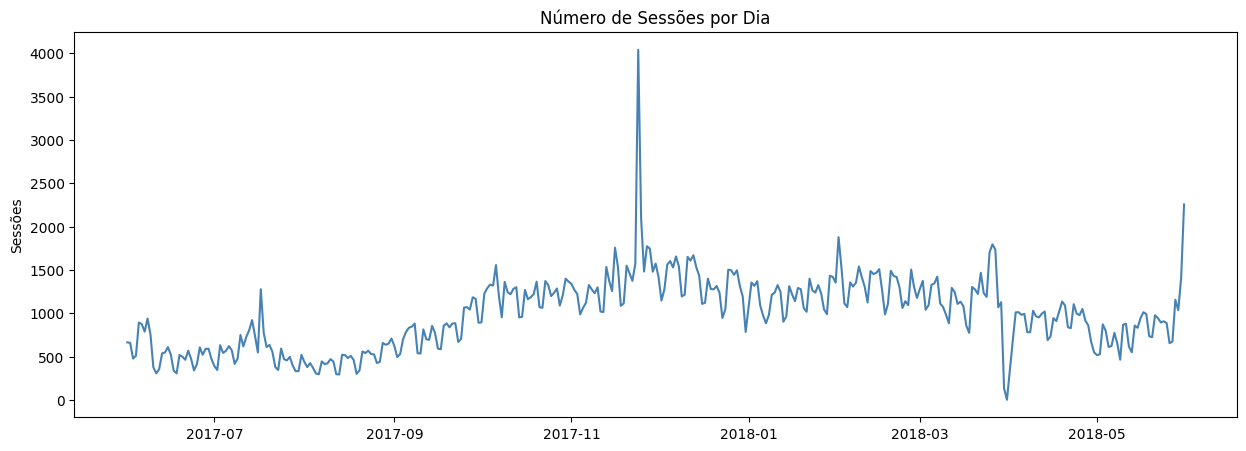

In [47]:
plt.figure(figsize=(15,5))

sessions_per_day.plot(color='steelblue')

plt.title('Número de Sessões por Dia')
plt.xlabel('')
plt.ylabel('Sessões')

plt.show()

### Conclusão

O volume diário de sessões permite avaliar o nível de atividade da plataforma ao longo do tempo.

Oscilações podem indicar efeitos de sazonalidade, campanhas de marketing ou alterações no comportamento dos usuários. Uma tendência consistente de crescimento nas sessões normalmente representa aumento no uso do produto.

### 2.2.2 Duração das Sessões

A duração das sessões é uma importante métrica de engajamento, pois indica quanto tempo os usuários permanecem utilizando a plataforma durante cada visita.

Antes da análise, foi verificada a existência de sessões com duração inválida. Como os dados já foram tratados durante a preparação, não foram encontradas sessões negativas nesta etapa. Dessa forma, podemos seguir para a análise da distribuição e das estatísticas descritivas.

In [48]:
# Calculando a duração das sessões em segundos
visits['session_duration_sec'] = (
    visits['End Ts'] - visits['Start Ts']
).dt.total_seconds()

In [49]:
# Identificando sessões com duração negativa

invalid_sessions = visits[
    visits['session_duration_sec'] < 0
]

print(f'Sessões inválidas encontradas: {len(invalid_sessions)}')

Sessões inválidas encontradas: 2


### Tratamento das sessões inválidas

Foram identificadas 2 sessões com duração negativa. Esses registros são inconsistentes, pois indicam que o horário de término da sessão ocorreu antes do horário de início.

Como a duração da sessão é calculada a partir da diferença entre esses dois horários, manter esses registros poderia distorcer as estatísticas descritivas e as análises posteriores.

Os 2 registros representam uma parcela muito pequena do conjunto de dados (2 de 359.400 sessões). Portanto, sua remoção não altera materialmente o volume de dados, mas garante que as métricas de duração sejam calculadas apenas com observações válidas.

In [50]:
# Removendo sessões com duração negativa

visits = visits[visits['session_duration_sec'] >= 0].copy()

print(f'Sessões válidas restantes: {len(visits):,}')

Sessões válidas restantes: 359,398


#### Estatísticas descritivas

Antes de analisar a distribuição da duração das sessões, serão calculadas estatísticas descritivas para compreender o comportamento geral dessa variável.

Serão observadas medidas como média, mediana, quartis e valores mínimos e máximos, que servirão de base para a interpretação dos resultados.

In [51]:
# Estatísticas descritivas da duração das sessões

print(visits['session_duration_sec'].describe())

count    359398.000000
mean        643.042287
std         997.105212
min           0.000000
25%         120.000000
50%         300.000000
75%         840.000000
max       42660.000000
Name: session_duration_sec, dtype: float64


Os resultados mostram que a duração média das sessões é de aproximadamente 643 segundos, enquanto a mediana é de 300 segundos. A diferença entre essas medidas indica uma distribuição assimétrica, influenciada por sessões de duração mais elevada.

Metade das sessões apresenta duração de até 300 segundos, enquanto 75% das sessões têm duração de até 840 segundos. O valor máximo de 42.660 segundos indica a existência de sessões muito mais longas que a maioria, o que contribui para elevar a média.

Por esse motivo, a mediana é uma medida complementar importante para representar o comportamento típico das sessões.

#### Distribuição da duração das sessões

Além das estatísticas descritivas, a distribuição da duração das sessões será analisada por meio de um histograma, permitindo identificar a concentração dos dados, possíveis assimetrias e a presença de valores extremos.

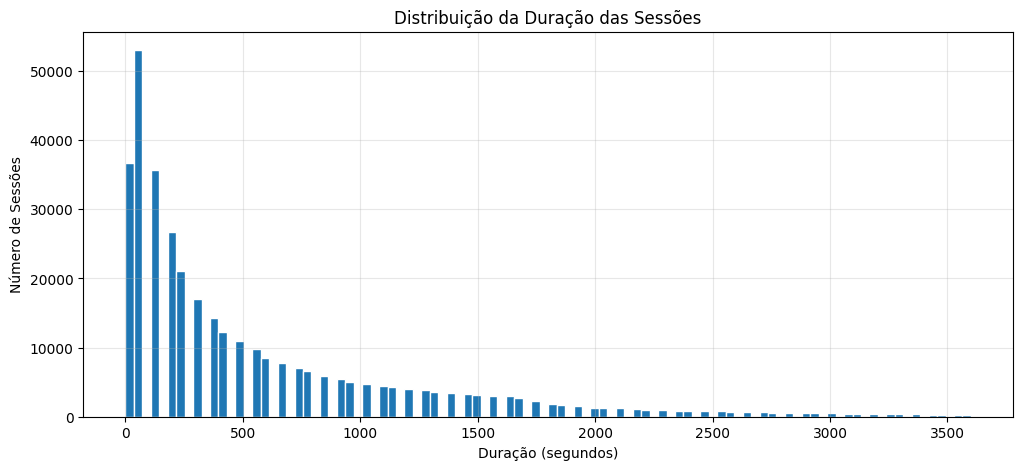

In [52]:
plt.figure(figsize=(12,5))

plt.hist(
    visits['session_duration_sec'],
    bins=100,
    range=(0,3600),
    edgecolor='white'
)

plt.title('Distribuição da Duração das Sessões')
plt.xlabel('Duração (segundos)')
plt.ylabel('Número de Sessões')

plt.grid(alpha=0.3)

plt.show()

#### Interpretação da distribuição

O histograma mostra uma distribuição fortemente assimétrica à direita, com grande concentração de sessões nas menores durações e uma redução gradual da frequência à medida que a duração aumenta.

A maior concentração está nos primeiros intervalos de duração, enquanto uma quantidade menor de sessões apresenta durações significativamente mais longas, formando uma cauda extensa à direita.

Esse comportamento indica que a maioria dos usuários realiza sessões relativamente curtas, enquanto uma parcela menor permanece na plataforma por períodos muito mais longos. A presença dessa cauda explica por que valores extremos podem influenciar a duração média das sessões.

#### Medidas de tendência central

Para complementar a análise, serão calculadas as principais medidas de tendência central: média, mediana e moda.

Essas métricas permitem comparar diferentes formas de representar a duração típica das sessões.

In [53]:
# Calculando medidas de tendência central

asl = visits['session_duration_sec'].mean()
median_session = visits['session_duration_sec'].median()
mode_session = visits['session_duration_sec'].mode()[0]

print(f'Duração média: {asl:.2f} segundos')
print(f'Mediana: {median_session:.2f} segundos')
print(f'Moda: {mode_session:.0f} segundos')

Duração média: 643.04 segundos
Mediana: 300.00 segundos
Moda: 60 segundos


#### Interpretação das medidas de tendência central

A duração média das sessões é de 643,04 segundos, enquanto a mediana é de 300 segundos e a moda é de 60 segundos.

A média é significativamente superior à mediana, o que confirma a influência das sessões mais longas identificadas no histograma. A mediana representa melhor o comportamento típico do usuário, indicando que metade das sessões dura até 300 segundos.

A moda de 60 segundos mostra que esse é o intervalo de duração mais frequente entre as sessões. Em conjunto, as três medidas reforçam a conclusão de que a maior parte das sessões é relativamente curta, enquanto uma parcela menor de sessões muito longas eleva a média.

#### Conclusão sobre a duração das sessões

A análise indica que a maioria das sessões é relativamente curta, com duração típica de até 300 segundos. A média de 643,04 segundos é elevada em relação à mediana devido à presença de uma parcela menor de sessões muito longas.

Dessa forma, a mediana de 300 segundos representa melhor o comportamento típico dos usuários do que a média. A distribuição também evidencia uma cauda longa à direita, indicando que alguns usuários permanecem na plataforma por períodos significativamente superiores ao padrão observado.

### 2.2.3 Frequência de retorno dos usuários

Para avaliar a frequência com que os usuários retornam à plataforma, será analisado o comportamento de retorno a partir da primeira sessão registrada de cada usuário.

Essa análise permite identificar se os usuários utilizam o produto de forma pontual ou se retornam ao longo do tempo, fornecendo uma indicação do nível de retenção e engajamento da plataforma.

#### Identificação da primeira sessão de cada usuário

Para determinar o comportamento de retorno, primeiro é necessário identificar quando cada usuário acessou a plataforma pela primeira vez.

A primeira sessão de cada usuário será utilizada como ponto de referência para medir os retornos posteriores e definir as respectivas coortes.

In [54]:
# Identificando a primeira sessão de cada usuário

first_visit = (
    visits
    .groupby('Uid')['Start Ts']
    .min()
    .reset_index()
    .rename(columns={'Start Ts': 'first_visit_date'})
)

# Adicionando a primeira sessão ao DataFrame de visitas

visits = visits.merge(
    first_visit,
    on='Uid',
    how='left'
)

print(visits[['Uid', 'Start Ts', 'first_visit_date']].head())

                    Uid            Start Ts    first_visit_date
0  16879256277535980062 2017-12-20 17:20:00 2017-12-20 17:20:00
1    104060357244891740 2018-02-19 16:53:00 2018-02-19 16:53:00
2   7459035603376831527 2017-07-01 01:54:00 2017-07-01 01:54:00
3  16174680259334210214 2018-05-20 10:59:00 2018-03-09 20:05:00
4   9969694820036681168 2017-12-27 14:06:00 2017-12-27 14:06:00


#### Identificação das coortes de usuários

Para comparar o comportamento de retorno dos usuários ao longo do tempo, os usuários serão agrupados de acordo com o mês em que realizaram sua primeira sessão.

Essa abordagem permite comparar diferentes grupos de usuários a partir de um mesmo ponto de partida e observar como a frequência de retorno evolui nos períodos seguintes.

In [55]:
# Criando a coorte mensal de cada usuário

visits['first_visit_month'] = (
    visits['first_visit_date']
    .dt.to_period('M')
)

print(
    visits[['Uid', 'first_visit_date', 'first_visit_month']]
    .head(10)
)

                    Uid    first_visit_date first_visit_month
0  16879256277535980062 2017-12-20 17:20:00           2017-12
1    104060357244891740 2018-02-19 16:53:00           2018-02
2   7459035603376831527 2017-07-01 01:54:00           2017-07
3  16174680259334210214 2018-03-09 20:05:00           2018-03
4   9969694820036681168 2017-12-27 14:06:00           2017-12
5  16007536194108375387 2017-09-03 21:35:00           2017-09
6   6661610529277171451 2017-06-29 09:00:00           2017-06
7  11423865690854540312 2017-11-05 15:14:00           2017-11
8   2987360259350925644 2017-07-19 10:41:00           2017-07
9   1289240080042562063 2017-11-08 13:42:00           2017-11


#### Identificação do mês de cada sessão

Depois de definir o mês de entrada de cada usuário, será identificado o mês em que cada uma de suas sessões ocorreu.

A comparação entre o mês da primeira sessão e o mês de cada sessão posterior permitirá determinar em quais períodos os usuários retornaram à plataforma.

In [56]:
# Identificando o mês de cada sessão

visits['session_month'] = (
    visits['Start Ts']
    .dt.to_period('M')
)

print(
    visits[['Uid', 'first_visit_month', 'session_month']]
    .head(10)
)

                    Uid first_visit_month session_month
0  16879256277535980062           2017-12       2017-12
1    104060357244891740           2018-02       2018-02
2   7459035603376831527           2017-07       2017-07
3  16174680259334210214           2018-03       2018-05
4   9969694820036681168           2017-12       2017-12
5  16007536194108375387           2017-09       2017-09
6   6661610529277171451           2017-06       2018-01
7  11423865690854540312           2017-11       2017-11
8   2987360259350925644           2017-07       2017-07
9   1289240080042562063           2017-11       2017-11


#### Cálculo do período desde a primeira sessão

Para medir a frequência de retorno, será calculado o número de meses entre o mês da primeira sessão e o mês de cada sessão posterior.

O valor 0 representa o mês em que o usuário iniciou sua utilização da plataforma. Valores maiores representam o número de meses decorridos desde a primeira sessão, permitindo acompanhar a permanência dos usuários ao longo do tempo.

In [57]:
# Calculando o número de meses desde a primeira sessão

visits['cohort_month'] = (
    visits['session_month'] - visits['first_visit_month']
).apply(lambda x: x.n)

print(
    visits[['Uid', 'first_visit_month', 'session_month', 'cohort_month']]
    .head(10)
)

                    Uid first_visit_month session_month  cohort_month
0  16879256277535980062           2017-12       2017-12             0
1    104060357244891740           2018-02       2018-02             0
2   7459035603376831527           2017-07       2017-07             0
3  16174680259334210214           2018-03       2018-05             2
4   9969694820036681168           2017-12       2017-12             0
5  16007536194108375387           2017-09       2017-09             0
6   6661610529277171451           2017-06       2018-01             7
7  11423865690854540312           2017-11       2017-11             0
8   2987360259350925644           2017-07       2017-07             0
9   1289240080042562063           2017-11       2017-11             0


#### Retenção por coorte

A partir do intervalo em meses desde a primeira sessão, será calculada a retenção dos usuários por coorte.

Para cada coorte mensal, será contabilizado o número de usuários que realizaram pelo menos uma sessão em cada mês desde sua primeira visita. A retenção será expressa como a proporção de usuários da coorte que continuaram retornando à plataforma.

Essa análise permite comparar a permanência dos usuários ao longo do tempo, independentemente do mês em que eles iniciaram o uso do produto.

In [58]:
# Contando usuários únicos por coorte e mês de retorno

cohort_data = (
    visits
    .groupby(['first_visit_month', 'cohort_month'])['Uid']
    .nunique()
    .reset_index()
)

cohort_data.columns = [
    'first_visit_month',
    'cohort_month',
    'users'
]

print(cohort_data.head(10))

  first_visit_month  cohort_month  users
0           2017-06             0  13259
1           2017-06             1   1043
2           2017-06             2    713
3           2017-06             3    814
4           2017-06             4    909
5           2017-06             5    947
6           2017-06             6    809
7           2017-06             7    766
8           2017-06             8    694
9           2017-06             9    674


#### Cálculo da taxa de retenção

A tabela mostra o número absoluto de usuários que permaneceram ativos em cada período após a primeira sessão. No entanto, esses valores não permitem comparar diretamente diferentes coortes, pois cada coorte pode ter um número inicial diferente de usuários.

Para tornar a comparação possível, será calculada a taxa de retenção de cada período em relação ao tamanho inicial da respectiva coorte. Assim, o mês 0 representará 100% da coorte, enquanto os períodos seguintes mostrarão qual proporção dos usuários continuou retornando à plataforma.

In [59]:
# Identificando o tamanho inicial de cada coorte

cohort_sizes = (
    cohort_data[cohort_data['cohort_month'] == 0]
    [['first_visit_month', 'users']]
    .rename(columns={'users': 'cohort_users'})
)

print(cohort_sizes.head(10))

   first_visit_month  cohort_users
0            2017-06         13259
12           2017-07         13140
23           2017-08         10181
33           2017-09         16704
42           2017-10         25977
50           2017-11         27248
57           2017-12         25268
63           2018-01         22624
68           2018-02         22197
72           2018-03         20589


#### Cálculo da taxa de retenção

O tamanho inicial de cada coorte será associado aos respectivos períodos de retorno. A taxa de retenção será então calculada dividindo o número de usuários que retornaram em cada período pelo número de usuários que compunham a coorte no período inicial.

Dessa forma, será possível comparar a retenção entre coortes de diferentes tamanhos e acompanhar a proporção de usuários que permanece ativa ao longo dos meses.

In [60]:
# Associando o tamanho inicial de cada coorte aos períodos de retorno

cohort_data = cohort_data.merge(
    cohort_sizes,
    on='first_visit_month',
    how='left'
)

# Calculando a taxa de retenção

cohort_data['retention_rate'] = (
    cohort_data['users'] / cohort_data['cohort_users']
)

print(cohort_data.head(10))

  first_visit_month  cohort_month  users  cohort_users  retention_rate
0           2017-06             0  13259         13259        1.000000
1           2017-06             1   1043         13259        0.078664
2           2017-06             2    713         13259        0.053775
3           2017-06             3    814         13259        0.061392
4           2017-06             4    909         13259        0.068557
5           2017-06             5    947         13259        0.071423
6           2017-06             6    809         13259        0.061015
7           2017-06             7    766         13259        0.057772
8           2017-06             8    694         13259        0.052342
9           2017-06             9    674         13259        0.050833


#### Visualização da retenção por coorte

Para facilitar a comparação da retenção entre as diferentes coortes, será criada uma tabela de retenção em formato de mapa de calor.

As linhas representarão o mês em que os usuários realizaram sua primeira sessão, enquanto as colunas representarão o número de meses desde essa primeira sessão. Os valores indicarão a taxa de retenção de cada grupo e período.

Essa visualização permitirá identificar padrões de retenção, comparar o comportamento das diferentes coortes e observar em que momento ocorre a maior perda de usuários.

In [61]:
# Criando a tabela de retenção para a visualização

retention_table = cohort_data.pivot(
    index='first_visit_month',
    columns='cohort_month',
    values='retention_rate'
)

print(retention_table)

cohort_month        0         1         2         3         4         5   \
first_visit_month                                                          
2017-06            1.0  0.078664  0.053775  0.061392  0.068557  0.071423   
2017-07            1.0  0.056088  0.051294  0.056164  0.058219  0.048174   
2017-08            1.0  0.076908  0.062862  0.062764  0.050093  0.044004   
2017-09            1.0  0.085489  0.069205  0.050706  0.039392  0.037835   
2017-10            1.0  0.078608  0.052239  0.038958  0.034261  0.032221   
2017-11            1.0  0.078281  0.044113  0.038682  0.033727  0.023415   
2017-12            1.0  0.055802  0.037993  0.031107  0.020263  0.019036   
2018-01            1.0  0.059715  0.039339  0.024973  0.020244       NaN   
2018-02            1.0  0.057080  0.025454  0.020093       NaN       NaN   
2018-03            1.0  0.041818  0.027053       NaN       NaN       NaN   
2018-04            1.0  0.048380       NaN       NaN       NaN       NaN   
2018-05     

#### Mapa de calor da retenção por coorte

A tabela de retenção será representada por meio de um mapa de calor, facilitando a identificação de padrões entre as diferentes coortes e períodos de retorno.

As linhas representam o mês da primeira sessão dos usuários, enquanto as colunas representam o número de meses decorridos desde essa primeira sessão. A intensidade das células representa a taxa de retenção observada em cada período.

Os valores ausentes nas últimas colunas correspondem às coortes mais recentes, que ainda não possuem meses suficientes de observação para esses períodos. Esses valores não serão tratados como retenção igual a zero.

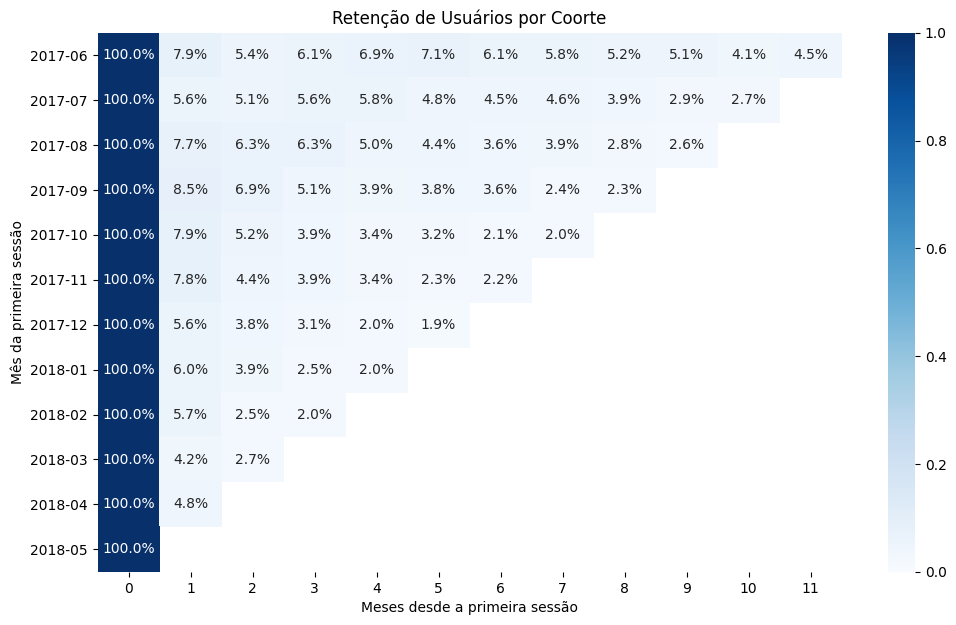

In [62]:
# Criando o mapa de calor da retenção por coorte

plt.figure(figsize=(12, 7))

sns.heatmap(
    retention_table,
    annot=True,
    fmt='.1%',
    cmap='Blues',
    vmin=0,
    vmax=1
)

plt.title('Retenção de Usuários por Coorte')
plt.xlabel('Meses desde a primeira sessão')
plt.ylabel('Mês da primeira sessão')

plt.show()

#### Interpretação da retenção por coorte

O mapa de calor mostra uma queda acentuada na retenção após o primeiro mês em todas as coortes analisadas. No primeiro mês após a aquisição, as taxas de retenção variam aproximadamente entre 4,2% e 8,5%, indicando que apenas uma pequena parcela dos usuários retorna à plataforma.

A coorte de setembro de 2017 apresenta a maior retenção no primeiro mês, com 8,5%, seguida pelas coortes de outubro de 2017, junho de 2017 e novembro de 2017, todas próximas de 8%.

Após os primeiros meses, a retenção continua diminuindo na maioria das coortes. A coorte de junho de 2017 apresenta um comportamento relativamente mais estável nos períodos seguintes, mantendo 5,1% dos usuários no mês 9 e 4,5% no mês 11.

De forma geral, os resultados indicam que a maior parte dos usuários não retorna à plataforma nos meses seguintes à primeira sessão. Portanto, a retenção representa um ponto de atenção para o produto e deve ser considerada nas análises posteriores de aquisição e monetização.

## 2.3 Vendas

Nesta etapa, será analisado o comportamento de compra dos usuários, considerando o momento em que realizam sua primeira compra, a frequência de pedidos e o valor gerado para a empresa.

A análise permitirá compreender o processo de conversão dos usuários em clientes e avaliar o valor econômico gerado ao longo de sua jornada.

### 2.3.1 Momento da primeira compra

Para identificar quando os usuários começam a comprar, será determinada a primeira compra registrada de cada usuário.

Como o conjunto de dados não possui uma informação específica sobre a data de cadastro ou registro, a primeira sessão registrada na plataforma será utilizada como ponto de referência para a jornada do usuário.

O intervalo entre a primeira sessão e a primeira compra permitirá analisar o tempo necessário para a conversão e identificar em que momento os usuários passam de visitantes a clientes.

In [63]:
# Identificando a primeira compra de cada usuário

first_order = (
    orders
    .groupby('Uid')['Buy Ts']
    .min()
    .reset_index()
    .rename(columns={'Buy Ts': 'first_order_date'})
)

print(first_order.head())

                Uid    first_order_date
0   313578113262317 2018-01-03 21:51:00
1  1575281904278712 2017-06-03 10:13:00
2  2429014661409475 2017-10-11 18:33:00
3  2464366381792757 2018-01-28 15:54:00
4  2551852515556206 2017-11-24 10:14:00


#### Associação da primeira compra aos usuários

A data da primeira compra será associada aos respectivos usuários no conjunto de dados de pedidos.

Essa informação será utilizada como referência para comparar o momento da primeira compra com a primeira sessão registrada, permitindo calcular o tempo decorrido até a conversão.

In [64]:
# Adicionando a data da primeira compra ao DataFrame de pedidos

orders = orders.merge(
    first_order,
    on='Uid',
    how='left'
)

print(
    orders[['Uid', 'Buy Ts', 'first_order_date']]
    .head()
)

                    Uid              Buy Ts    first_order_date
0  10329302124590727494 2017-06-01 00:10:00 2017-06-01 00:10:00
1  11627257723692907447 2017-06-01 00:25:00 2017-06-01 00:25:00
2  17903680561304213844 2017-06-01 00:27:00 2017-06-01 00:27:00
3  16109239769442553005 2017-06-01 00:29:00 2017-06-01 00:29:00
4  14200605875248379450 2017-06-01 07:58:00 2017-06-01 07:58:00


#### Tempo até a primeira compra

Para medir o tempo necessário para a conversão, será calculado o intervalo entre a primeira sessão registrada e a primeira compra de cada usuário.

O intervalo será expresso em dias, permitindo identificar em quanto tempo os usuários que realizaram uma compra passaram da primeira interação com a plataforma para a conversão.

Essa análise também permitirá observar a concentração das conversões nos primeiros dias após a aquisição.

In [65]:
# Adicionando a data da primeira sessão ao DataFrame de pedidos

orders = orders.merge(
    first_visit,
    on='Uid',
    how='left'
)

print(
    orders[['Uid', 'first_visit_date', 'first_order_date']]
    .head()
)

                    Uid    first_visit_date    first_order_date
0  10329302124590727494 2017-06-01 00:09:00 2017-06-01 00:10:00
1  11627257723692907447 2017-06-01 00:14:00 2017-06-01 00:25:00
2  17903680561304213844 2017-06-01 00:25:00 2017-06-01 00:27:00
3  16109239769442553005 2017-06-01 00:14:00 2017-06-01 00:29:00
4  14200605875248379450 2017-06-01 07:31:00 2017-06-01 07:58:00


#### Cálculo do tempo até a conversão

Com as datas da primeira sessão e da primeira compra disponíveis no mesmo conjunto de dados, será calculado o intervalo entre esses dois eventos.

O intervalo será inicialmente calculado em dias, preservando também a precisão temporal dos dados. Valores próximos de zero representarão usuários que realizaram a primeira compra no mesmo dia da primeira sessão, enquanto valores maiores indicarão um período mais longo até a conversão.

In [66]:
# Calculando o tempo entre a primeira sessão e a primeira compra

orders['conversion_time_days'] = (
    orders['first_order_date'] - orders['first_visit_date']
).dt.total_seconds() / (24 * 60 * 60)

print(orders[['Uid', 'first_visit_date', 'first_order_date', 'conversion_time_days']].head())

                    Uid    first_visit_date    first_order_date  \
0  10329302124590727494 2017-06-01 00:09:00 2017-06-01 00:10:00   
1  11627257723692907447 2017-06-01 00:14:00 2017-06-01 00:25:00   
2  17903680561304213844 2017-06-01 00:25:00 2017-06-01 00:27:00   
3  16109239769442553005 2017-06-01 00:14:00 2017-06-01 00:29:00   
4  14200605875248379450 2017-06-01 07:31:00 2017-06-01 07:58:00   

   conversion_time_days  
0              0.000694  
1              0.007639  
2              0.001389  
3              0.010417  
4              0.018750  


#### Distribuição do tempo até a conversão

Para compreender quando os usuários realizam sua primeira compra, será analisada a distribuição do tempo decorrido entre a primeira sessão e a primeira compra.

A análise permitirá identificar se a conversão ocorre predominantemente no mesmo dia da primeira interação ou se os usuários costumam precisar de mais tempo para realizar a primeira compra.

#### Preparação dos dados para a análise da conversão

Como a análise do tempo até a primeira compra deve considerar cada usuário uma única vez, será utilizada uma observação por usuário.

O conjunto de pedidos contém usuários que podem realizar vários pedidos, portanto, utilizar diretamente todas as linhas poderia dar maior peso aos usuários com maior número de compras. Para evitar essa distorção, serão mantidos apenas os registros únicos de cada usuário com sua primeira compra.

In [67]:
# Criando uma base com uma observação por usuário

conversion_data = (
    orders[
        ['Uid', 'first_visit_date', 'first_order_date', 'conversion_time_days']
    ]
    .drop_duplicates('Uid')
    .copy()
)

print(conversion_data.head())
print(f'Usuários com primeira compra: {len(conversion_data):,}')

                    Uid    first_visit_date    first_order_date  \
0  10329302124590727494 2017-06-01 00:09:00 2017-06-01 00:10:00   
1  11627257723692907447 2017-06-01 00:14:00 2017-06-01 00:25:00   
2  17903680561304213844 2017-06-01 00:25:00 2017-06-01 00:27:00   
3  16109239769442553005 2017-06-01 00:14:00 2017-06-01 00:29:00   
4  14200605875248379450 2017-06-01 07:31:00 2017-06-01 07:58:00   

   conversion_time_days  
0              0.000694  
1              0.007639  
2              0.001389  
3              0.010417  
4              0.018750  
Usuários com primeira compra: 36,523


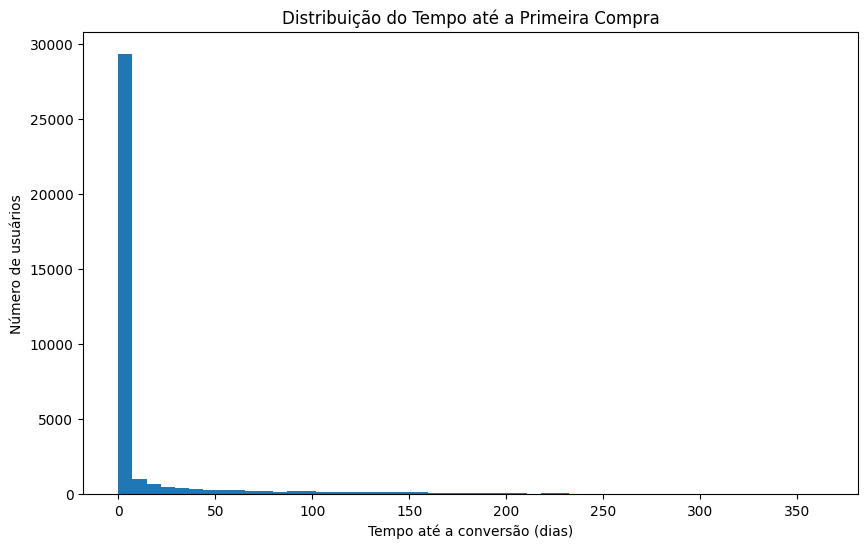

In [68]:
# Visualizando a distribuição do tempo até a primeira compra

plt.figure(figsize=(10, 6))

plt.hist(
    conversion_data['conversion_time_days'],
    bins=50
)

plt.title('Distribuição do Tempo até a Primeira Compra')
plt.xlabel('Tempo até a conversão (dias)')
plt.ylabel('Número de usuários')

plt.show()

#### Interpretação da distribuição do tempo até a conversão

A distribuição apresenta uma forte concentração das primeiras compras nos primeiros dias após a primeira sessão. A maior parte das conversões ocorre próxima ao início da jornada do usuário, enquanto uma parcela menor realiza a primeira compra após períodos mais longos.

O gráfico apresenta uma distribuição assimétrica à direita, com uma cauda longa que representa usuários cujo processo de conversão demora mais tempo.

Esse comportamento indica que a decisão de compra ocorre principalmente no início da jornada, tornando os primeiros dias após a aquisição um período relevante para ações de conversão e comunicação com os usuários.

#### Estatísticas do tempo até a conversão

Para complementar a análise da distribuição, serão calculadas a média, a mediana e os quartis do tempo entre a primeira sessão e a primeira compra.

Essas medidas permitirão quantificar o comportamento observado no gráfico e comparar o tempo típico de conversão com os valores mais elevados da distribuição.

In [69]:
# Calculando estatísticas do tempo até a conversão

print(conversion_data['conversion_time_days'].describe())

count    36523.000000
mean        16.902900
std         47.072760
min          0.000000
25%          0.002778
50%          0.011111
75%          2.011806
max        363.294444
Name: conversion_time_days, dtype: float64


#### Interpretação das estatísticas de conversão

As estatísticas confirmam a forte assimetria observada no histograma. A mediana do tempo até a primeira compra é de aproximadamente 16 minutos, indicando que metade dos usuários que realizaram uma compra converteu-se nesse intervalo.

O primeiro quartil corresponde a aproximadamente 4 minutos, enquanto o terceiro quartil está próximo de 2 dias. Isso mostra que a maior parte das conversões ocorre rapidamente, embora exista uma parcela de usuários que demora significativamente mais tempo para realizar a primeira compra.

A média de 16,9 dias é muito superior à mediana devido à presença de uma cauda longa, formada por usuários que converteram após períodos mais extensos. Por esse motivo, a mediana é uma medida mais representativa do tempo típico de conversão neste conjunto de dados.

#### Conclusão da análise de conversão

A análise mostra que a maior parte dos usuários que realizam uma compra converte rapidamente após a primeira interação com a plataforma. A mediana do tempo até a primeira compra é de aproximadamente 16 minutos, enquanto 75% dos usuários que compraram realizaram a primeira compra em até aproximadamente 2 dias.

Ao mesmo tempo, a diferença entre a mediana e a média, que chega a 16,9 dias, evidencia a existência de uma parcela de usuários com um tempo de conversão muito mais longo. Esses usuários formam uma cauda extensa na distribuição e elevam a média.

Dessa forma, os primeiros dias após a aquisição representam um período especialmente importante para estimular a conversão, embora também exista um grupo de usuários que pode converter posteriormente.

### 2.3.2 Número de pedidos por cliente

Para avaliar a frequência de compra dos clientes, será analisado o número de pedidos realizados por cada usuário durante o período observado.

Essa métrica permite identificar se os clientes realizam principalmente uma única compra ou se existe um comportamento de recompra. A distribuição do número de pedidos também será utilizada para avaliar o nível de recorrência dos clientes e compreender melhor o comportamento de compra na plataforma.

In [70]:
# Contando o número de pedidos realizados por cada cliente

orders_per_user = (
    orders
    .groupby('Uid')
    .size()
    .reset_index(name='orders_count')
)

print(orders_per_user.head())

                Uid  orders_count
0   313578113262317             1
1  1575281904278712             2
2  2429014661409475             1
3  2464366381792757             1
4  2551852515556206             2


#### Distribuição do número de pedidos por cliente

A distribuição do número de pedidos apresenta uma concentração elevada nos menores valores, acompanhada por uma cauda de clientes com maior frequência de compra.

Para facilitar a visualização desse comportamento, a análise gráfica será concentrada nos valores mais frequentes de pedidos por cliente, evitando que valores extremos comprometam a leitura do gráfico.

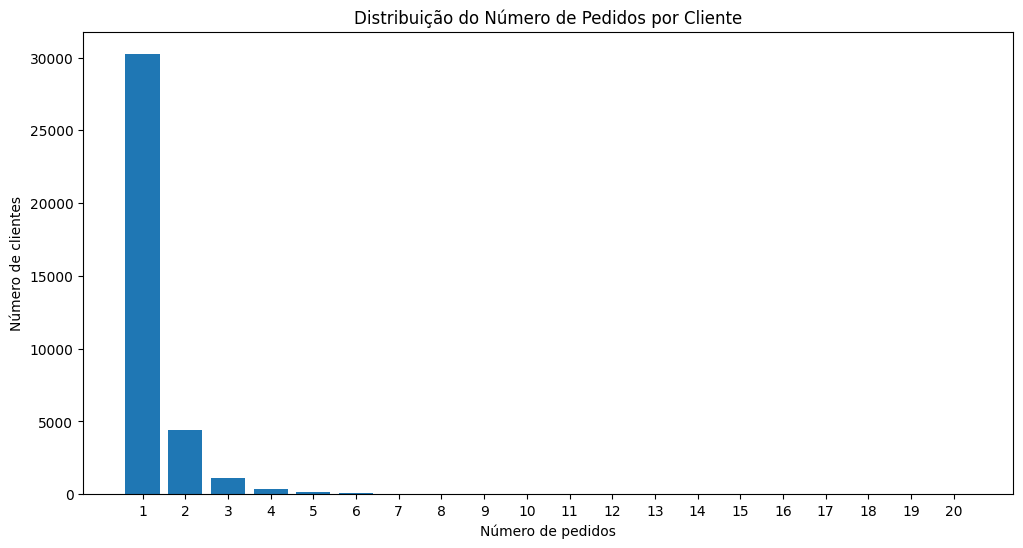

In [71]:
# Visualizando os números de pedidos mais frequentes por cliente

order_distribution = (
    orders_per_user['orders_count']
    .value_counts()
    .sort_index()
)

top_order_counts = order_distribution.head(20)

plt.figure(figsize=(12, 6))

plt.bar(
    top_order_counts.index.astype(str),
    top_order_counts.values
)

plt.title('Distribuição do Número de Pedidos por Cliente')
plt.xlabel('Número de pedidos')
plt.ylabel('Número de clientes')

plt.show()

#### Estatísticas da frequência de pedidos

Para complementar a análise da distribuição, serão calculadas estatísticas descritivas do número de pedidos por cliente.

A média, a mediana, os quartis e os valores mínimo e máximo permitirão quantificar a frequência de compra e avaliar a diferença entre o comportamento típico dos clientes e os clientes com maior número de pedidos.

In [72]:
# Calculando estatísticas do número de pedidos por cliente

print(orders_per_user['orders_count'].describe())

count    36523.000000
mean         1.380363
std          3.454461
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max        239.000000
Name: orders_count, dtype: float64


#### Interpretação da frequência de pedidos

As estatísticas mostram que a frequência de compra está fortemente concentrada em uma única compra. A mediana e os três primeiros quartis correspondem a 1 pedido, indicando que pelo menos 75% dos clientes realizaram apenas um pedido durante o período analisado.

A média de 1,38 pedidos por cliente é superior à mediana devido à existência de uma parcela menor de clientes com maior frequência de compra. Essa diferença também é refletida pelo desvio-padrão de 3,45 e pelo valor máximo de 239 pedidos para um único cliente.

Portanto, a média isoladamente não representa adequadamente o comportamento típico dos clientes. A mediana e os quartis indicam que a recompra está concentrada em uma parcela relativamente pequena da base de clientes.

#### Conclusão da frequência de pedidos

A análise indica que a maioria dos clientes realizou apenas uma compra durante o período observado, enquanto uma parcela menor apresentou comportamento de recompra.

Esse resultado sugere que a recorrência de compra é um ponto de atenção para o negócio. Embora existam clientes com elevada frequência de pedidos, eles representam uma parcela pequena da base, fazendo com que a média de 1,38 pedidos por cliente seja influenciada por esses clientes mais recorrentes.

Assim, estratégias voltadas para aumentar a recompra e estimular a fidelização podem representar uma oportunidade relevante para aumentar o valor gerado por cliente.

### 2.3.3 Receita por cliente

Para avaliar o valor gerado pelos clientes, será analisada a receita total associada a cada usuário durante o período observado.

Essa análise permitirá identificar quanto cada cliente contribui para a receita e verificar se a distribuição do valor das compras está concentrada em uma parcela específica da base.

Também será observada a diferença entre o comportamento típico dos clientes e aqueles que apresentam valores de compra mais elevados.

In [73]:
# Calculando a receita total por cliente

revenue_per_user = (
    orders
    .groupby('Uid')['Revenue']
    .sum()
    .reset_index(name='total_revenue')
)

print(revenue_per_user.head())

                Uid  total_revenue
0   313578113262317           0.55
1  1575281904278712           3.05
2  2429014661409475          73.33
3  2464366381792757           2.44
4  2551852515556206          10.99


#### Distribuição da receita por cliente

Para compreender como a receita está distribuída entre os clientes, será analisada a distribuição da receita total gerada por cada usuário.

A visualização permitirá identificar se a receita está concentrada em valores mais baixos ou se existe uma parcela de clientes que gera valores significativamente superiores aos demais.

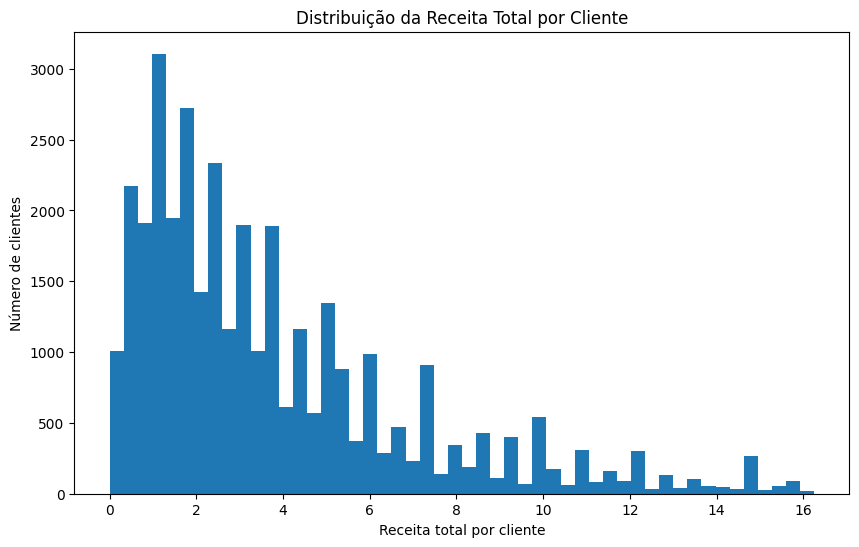

In [74]:
# Visualizando a distribuição da receita por cliente

revenue_limit = revenue_per_user['total_revenue'].quantile(0.95)

plt.figure(figsize=(10, 6))

plt.hist(
    revenue_per_user['total_revenue'],
    bins=50,
    range=(0, revenue_limit)
)

plt.title('Distribuição da Receita Total por Cliente')
plt.xlabel('Receita total por cliente')
plt.ylabel('Número de clientes')

plt.show()

#### Estatísticas da receita por cliente

Para complementar a análise da distribuição da receita, serão calculadas estatísticas descritivas da receita total por cliente.

A média, a mediana, os quartis e os valores mínimo e máximo permitirão avaliar o valor típico gerado por cliente e identificar a influência de clientes com receitas significativamente superiores à maior parte da base.

In [75]:
# Calculando estatísticas da receita por cliente

print(revenue_per_user['total_revenue'].describe())

count    36523.000000
mean         6.901328
std         88.128535
min          0.000000
25%          1.470000
50%          3.050000
75%          5.800000
max      11810.180000
Name: total_revenue, dtype: float64


#### Interpretação da receita por cliente

A distribuição da receita por cliente apresenta forte assimetria à direita, com a maior parte dos clientes concentrada em valores relativamente baixos e uma pequena parcela gerando receitas significativamente superiores.

A mediana de €3,05 indica que metade dos clientes gerou até esse valor, enquanto 75% dos clientes geraram até €5,80. A média de €6,90 é superior à mediana, refletindo a influência de clientes com receitas muito elevadas.

O valor máximo de €11.810,18 e o elevado desvio-padrão de €88,13 reforçam a presença de valores extremos. Dessa forma, a mediana é uma medida mais representativa da receita típica por cliente do que a média.

#### Conclusão da receita por cliente

A análise mostra que a receita gerada por cliente está fortemente concentrada em valores baixos, enquanto uma pequena parcela de clientes apresenta receitas muito superiores.

A mediana de €3,05 representa melhor o comportamento típico da base do que a média de €6,90, que é influenciada pelos clientes de maior valor. Esse comportamento evidencia que a contribuição para a receita não é distribuída de forma uniforme entre os clientes.

Assim, além de acompanhar a aquisição de novos clientes, é importante considerar estratégias de retenção e aumento do valor gerado pelos clientes ao longo do tempo.

### 2.3.4 LTV por coorte

Para avaliar o valor gerado pelos clientes ao longo do tempo, será calculado o LTV (Lifetime Value) por coorte.

O LTV representa o valor acumulado gerado por um cliente ao longo do seu ciclo de vida. A análise por coortes permite acompanhar esse valor de acordo com o mês em que os clientes realizaram a primeira compra, tornando possível comparar a evolução do valor gerado entre diferentes grupos de clientes.

Para o cálculo, será considerada a receita gerada por cada coorte ao longo dos meses de vida, ajustada pela margem de lucro bruto.

#### Definição das coortes de compra

Para calcular o LTV, os clientes serão agrupados em coortes mensais de acordo com o mês em que realizaram a primeira compra.

Também será calculado o número de clientes em cada coorte, que será utilizado posteriormente para relacionar a receita gerada pela coorte ao número de clientes que a compõe.

In [76]:
# Criando as coortes mensais de primeira compra

first_orders = (
    orders[
        ['Uid', 'first_order_date']
    ]
    .drop_duplicates('Uid')
    .copy()
)

first_orders['first_order_month'] = (
    first_orders['first_order_date']
    .dt.to_period('M')
    .astype(str)
)

cohort_sizes = (
    first_orders
    .groupby('first_order_month')['Uid']
    .nunique()
    .reset_index(name='cohort_users')
)

print(cohort_sizes)

   first_order_month  cohort_users
0            2017-06          2023
1            2017-07          1923
2            2017-08          1370
3            2017-09          2581
4            2017-10          4340
5            2017-11          4081
6            2017-12          4383
7            2018-01          3373
8            2018-02          3651
9            2018-03          3533
10           2018-04          2276
11           2018-05          2988
12           2018-06             1


#### Associação das coortes aos pedidos

A coorte de primeira compra será adicionada a cada pedido realizado pelo respectivo cliente.

Dessa forma, cada pedido poderá ser relacionado tanto à coorte à qual o cliente pertence quanto ao mês em que o pedido foi realizado. Essa estrutura permitirá acompanhar a receita gerada pelas diferentes coortes ao longo dos meses.

In [77]:
# Adicionando a coorte de primeira compra aos pedidos

orders = orders.merge(
    first_orders[['Uid', 'first_order_month']],
    on='Uid',
    how='left'
)

print(
    orders[['Uid', 'Buy Ts', 'first_order_month']]
    .head()
)

                    Uid              Buy Ts first_order_month
0  10329302124590727494 2017-06-01 00:10:00           2017-06
1  11627257723692907447 2017-06-01 00:25:00           2017-06
2  17903680561304213844 2017-06-01 00:27:00           2017-06
3  16109239769442553005 2017-06-01 00:29:00           2017-06
4  14200605875248379450 2017-06-01 07:58:00           2017-06


#### Identificação do mês de cada pedido

Para acompanhar a receita gerada por cada coorte ao longo do tempo, será identificado o mês em que cada pedido foi realizado.

Essa informação será posteriormente combinada com o mês da primeira compra do cliente, permitindo comparar a receita gerada pelas coortes desde o momento da aquisição.

In [78]:
# Identificando o mês de cada pedido

orders['order_month'] = (
    orders['Buy Ts']
    .dt.to_period('M')
    .astype(str)
)

print(
    orders[['Uid', 'first_order_month', 'order_month', 'Revenue']]
    .head()
)

                    Uid first_order_month order_month  Revenue
0  10329302124590727494           2017-06     2017-06    17.00
1  11627257723692907447           2017-06     2017-06     0.55
2  17903680561304213844           2017-06     2017-06     0.37
3  16109239769442553005           2017-06     2017-06     0.55
4  14200605875248379450           2017-06     2017-06     0.37


#### Cálculo do tempo desde a primeira compra

Para acompanhar a evolução do valor gerado por cada coorte, será calculado o número de meses decorridos entre o mês da primeira compra e o mês de cada pedido.

O mês da primeira compra será considerado como mês 0. Assim, os pedidos realizados no mês seguinte pertencem ao mês 1 da vida da coorte, os realizados dois meses depois ao mês 2, e assim sucessivamente.

In [79]:
# Calculando o número de meses desde a primeira compra

orders['cohort_month'] = (
    pd.to_datetime(orders['order_month']).dt.to_period('M')
    - pd.to_datetime(orders['first_order_month']).dt.to_period('M')
).apply(lambda x: x.n)

print(
    orders[['Uid', 'first_order_month', 'order_month', 'cohort_month', 'Revenue']]
    .head()
)

                    Uid first_order_month order_month  cohort_month  Revenue
0  10329302124590727494           2017-06     2017-06             0    17.00
1  11627257723692907447           2017-06     2017-06             0     0.55
2  17903680561304213844           2017-06     2017-06             0     0.37
3  16109239769442553005           2017-06     2017-06             0     0.55
4  14200605875248379450           2017-06     2017-06             0     0.37


#### Receita gerada por coorte ao longo do tempo

A receita será agregada por coorte de primeira compra e por mês desde a aquisição.

Essa etapa permitirá acompanhar quanto cada grupo de clientes gerou de receita no mês inicial e nos meses seguintes, servindo como base para o cálculo do LTV acumulado.

In [80]:
# Calculando a receita por coorte e mês de vida

cohort_revenue = (
    orders
    .groupby(['first_order_month', 'cohort_month'])['Revenue']
    .sum()
    .reset_index(name='revenue')
)

print(cohort_revenue.head(10))

  first_order_month  cohort_month  revenue
0           2017-06             0  9557.49
1           2017-06             1   981.82
2           2017-06             2   885.34
3           2017-06             3  1931.30
4           2017-06             4  2068.58
5           2017-06             5  1487.92
6           2017-06             6  1922.74
7           2017-06             7  1176.56
8           2017-06             8  1119.15
9           2017-06             9  1225.51


#### Cálculo do LTV por coorte

Para calcular o LTV, a receita gerada em cada mês será dividida pelo número de clientes que compõem a respectiva coorte.

Esse cálculo permite obter o valor médio gerado por cliente em cada mês de vida da coorte. O LTV acumulado poderá então ser obtido pela soma desses valores ao longo dos meses.

In [81]:
# Calculando a receita média por cliente de cada coorte

cohort_ltv = cohort_revenue.merge(
    cohort_sizes,
    on='first_order_month',
    how='left'
)

cohort_ltv['ltv'] = (
    cohort_ltv['revenue'] /
    cohort_ltv['cohort_users']
)

print(cohort_ltv.head(10))

  first_order_month  cohort_month  revenue  cohort_users       ltv
0           2017-06             0  9557.49          2023  4.724414
1           2017-06             1   981.82          2023  0.485329
2           2017-06             2   885.34          2023  0.437637
3           2017-06             3  1931.30          2023  0.954671
4           2017-06             4  2068.58          2023  1.022531
5           2017-06             5  1487.92          2023  0.735502
6           2017-06             6  1922.74          2023  0.950440
7           2017-06             7  1176.56          2023  0.581592
8           2017-06             8  1119.15          2023  0.553213
9           2017-06             9  1225.51          2023  0.605788


#### Cálculo do lucro bruto e do LTV

De acordo com a metodologia de economia unitária, o LTV deve ser calculado com base no lucro bruto gerado por cada cliente, e não diretamente sobre a receita.

Considerando uma margem de lucro bruto de 50%, a receita de cada coorte será convertida em lucro bruto. Em seguida, o lucro bruto será dividido pelo número de clientes da respectiva coorte para obter o LTV por cliente em cada mês de vida.

In [82]:
# Calculando o lucro bruto e o LTV por cliente

margin_rate = 0.50

cohort_ltv['gross_profit'] = (
    cohort_ltv['revenue'] * margin_rate
)

cohort_ltv['ltv'] = (
    cohort_ltv['gross_profit'] /
    cohort_ltv['cohort_users']
)

print(cohort_ltv.head(10))

  first_order_month  cohort_month  revenue  cohort_users       ltv  \
0           2017-06             0  9557.49          2023  2.362207   
1           2017-06             1   981.82          2023  0.242664   
2           2017-06             2   885.34          2023  0.218819   
3           2017-06             3  1931.30          2023  0.477336   
4           2017-06             4  2068.58          2023  0.511265   
5           2017-06             5  1487.92          2023  0.367751   
6           2017-06             6  1922.74          2023  0.475220   
7           2017-06             7  1176.56          2023  0.290796   
8           2017-06             8  1119.15          2023  0.276607   
9           2017-06             9  1225.51          2023  0.302894   

   gross_profit  
0      4778.745  
1       490.910  
2       442.670  
3       965.650  
4      1034.290  
5       743.960  
6       961.370  
7       588.280  
8       559.575  
9       612.755  


#### LTV acumulado por coorte

Para avaliar a evolução do valor gerado por cliente ao longo do tempo, será calculado o LTV acumulado de cada coorte.

O LTV acumulado será obtido pela soma do LTV mensal desde o mês da primeira compra até cada mês subsequente. Dessa forma, será possível acompanhar como o valor médio gerado por cliente aumenta à medida que a relação com a plataforma se prolonga.

In [83]:
# Calculando o LTV acumulado por coorte

cohort_ltv = cohort_ltv.sort_values(
    ['first_order_month', 'cohort_month']
)

cohort_ltv['cumulative_ltv'] = (
    cohort_ltv
    .groupby('first_order_month')['ltv']
    .cumsum()
)

print(
    cohort_ltv[
        ['first_order_month', 'cohort_month', 'ltv', 'cumulative_ltv']
    ].head(10)
)

  first_order_month  cohort_month       ltv  cumulative_ltv
0           2017-06             0  2.362207        2.362207
1           2017-06             1  0.242664        2.604871
2           2017-06             2  0.218819        2.823690
3           2017-06             3  0.477336        3.301026
4           2017-06             4  0.511265        3.812291
5           2017-06             5  0.367751        4.180042
6           2017-06             6  0.475220        4.655262
7           2017-06             7  0.290796        4.946058
8           2017-06             8  0.276607        5.222664
9           2017-06             9  0.302894        5.525559


#### Tabela de LTV acumulado por coorte

Para comparar a evolução do LTV entre as diferentes coortes de clientes, será criada uma tabela em que cada linha representa o mês da primeira compra e cada coluna representa o mês de vida da coorte.

Essa estrutura permite observar a evolução do LTV acumulado ao longo do tempo e identificar diferenças no valor gerado por clientes adquiridos em diferentes períodos.

In [84]:
# Criando a tabela de LTV acumulado por coorte

ltv_cohort_table = cohort_ltv.pivot(
    index='first_order_month',
    columns='cohort_month',
    values='cumulative_ltv'
)

print(ltv_cohort_table)

cohort_month             0         1         2         3         4         5   \
first_order_month                                                               
2017-06            2.362207  2.604871  2.823690  3.301026  3.812291  4.180042   
2017-07            3.005109  3.172715  3.484480  3.663968  3.752363  3.830387   
2017-08            2.638259  2.874255  3.103496  3.299135  3.546161  3.687931   
2017-09            2.822265  3.381058  3.641523  5.629419  5.829698  6.153231   
2017-10            2.501866  2.769748  2.865445  2.944017  3.019797  3.079978   
2017-11            2.577341  2.776958  2.876736  3.039212  3.113219  3.140158   
2017-12            2.369095  2.499282  2.961831  3.494468  3.650933  3.819957   
2018-01            2.067818  2.215197  2.367338  2.438727  2.470076       NaN   
2018-02            2.078494  2.217631  2.256889  2.293961       NaN       NaN   
2018-03            2.419401  2.569847  2.727627       NaN       NaN       NaN   
2018-04            2.328798 

#### Visualização do LTV acumulado por coorte

Para facilitar a comparação entre as coortes, será utilizada uma visualização em formato de mapa de calor.

A intensidade dos valores permitirá identificar diferenças no LTV acumulado entre as coortes e observar como o valor gerado por cliente evolui ao longo dos meses de vida.

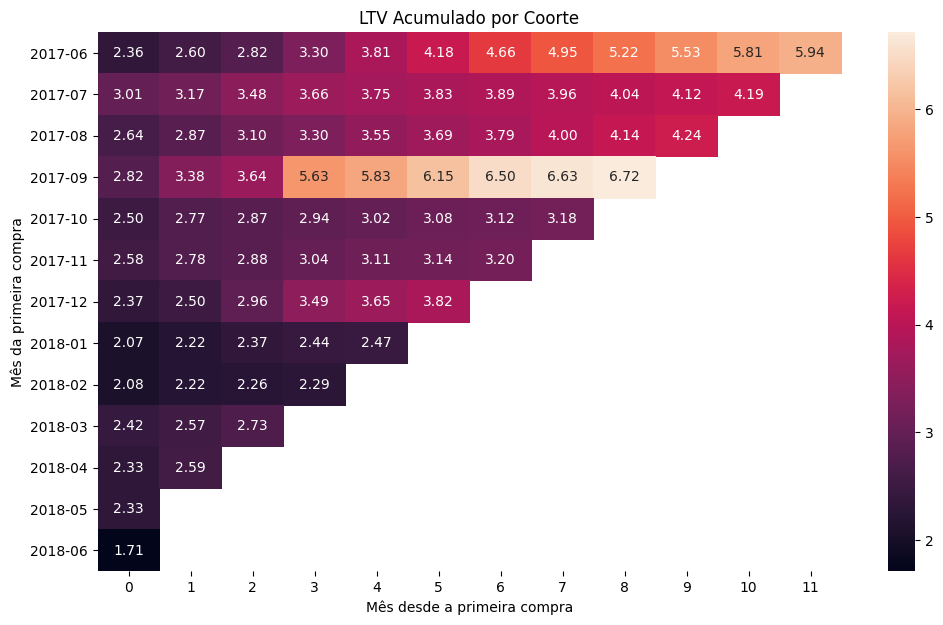

In [85]:
# Visualizando o LTV acumulado por coorte

plt.figure(figsize=(12, 7))

sns.heatmap(
    ltv_cohort_table,
    annot=True,
    fmt='.2f'
)

plt.title('LTV Acumulado por Coorte')
plt.xlabel('Mês desde a primeira compra')
plt.ylabel('Mês da primeira compra')

plt.show()

#### Interpretação do LTV por coorte

O LTV acumulado apresenta crescimento ao longo dos meses para todas as coortes, indicando que os clientes continuam gerando valor após a primeira compra.

Observa-se, porém, uma diferença relevante entre as coortes. A coorte de setembro de 2017 apresenta os maiores valores de LTV acumulado, atingindo aproximadamente €6,72 no mês 8. A coorte de junho de 2017 também apresenta crescimento consistente, chegando a aproximadamente €5,94 no mês 11.

As coortes mais recentes apresentam valores acumulados menores, mas essa diferença deve ser interpretada com cautela, pois essas coortes possuem menos meses de observação disponíveis. Por exemplo, a coorte de junho de 2018 possui apenas o mês 0 disponível.

De modo geral, o LTV acumulado demonstra que o valor gerado pelos clientes aumenta com a recorrência de compras, embora a intensidade desse crescimento varie entre as coortes.

### 2.3.5 Custo de aquisição de clientes (CAC)

Para avaliar quanto a empresa investe para adquirir novos clientes, será calculado o CAC (Customer Acquisition Cost).

O CAC representa o custo médio de aquisição de um cliente e será calculado para cada coorte mensal de primeira compra.

Para isso, serão relacionados os custos de marketing do mês ao número de novos clientes adquiridos naquele mesmo período. Essa métrica permitirá posteriormente comparar o custo de aquisição com o LTV e avaliar a eficiência da estratégia de aquisição.

In [86]:
print(costs.head())

   source_id         dt  costs
0          1 2017-06-01  75.20
1          1 2017-06-02  62.25
2          1 2017-06-03  36.53
3          1 2017-06-04  55.00
4          1 2017-06-05  57.08


#### Cálculo dos custos de marketing por mês

Como os custos de marketing estão registrados diariamente e o número de novos clientes foi calculado por mês, os custos serão agregados mensalmente.

Essa agregação permitirá comparar o investimento em marketing de cada mês com o número de clientes que realizaram sua primeira compra no mesmo período.

In [87]:
# Agregando os custos de marketing por mês

costs['cost_month'] = (
    costs['dt']
    .dt.to_period('M')
    .astype(str)
)

monthly_costs = (
    costs
    .groupby('cost_month')['costs']
    .sum()
    .reset_index()
)

print(monthly_costs)

   cost_month     costs
0     2017-06  18015.00
1     2017-07  18240.59
2     2017-08  14790.54
3     2017-09  24368.91
4     2017-10  36322.88
5     2017-11  37907.88
6     2017-12  38315.35
7     2018-01  33518.52
8     2018-02  32723.03
9     2018-03  30415.27
10    2018-04  22289.38
11    2018-05  22224.27


#### Relação entre custos de marketing e novos clientes

Os custos mensais de marketing serão relacionados ao número de novos clientes adquiridos em cada mês.

Essa combinação permitirá calcular o custo médio de aquisição de cada novo cliente, dividindo o investimento em marketing pelo número de clientes que realizaram sua primeira compra no respectivo período.

In [88]:
# Relacionando os custos de marketing ao número de novos clientes

cac_data = monthly_costs.merge(
    cohort_sizes,
    left_on='cost_month',
    right_on='first_order_month',
    how='left'
)

print(cac_data)

   cost_month     costs first_order_month  cohort_users
0     2017-06  18015.00           2017-06          2023
1     2017-07  18240.59           2017-07          1923
2     2017-08  14790.54           2017-08          1370
3     2017-09  24368.91           2017-09          2581
4     2017-10  36322.88           2017-10          4340
5     2017-11  37907.88           2017-11          4081
6     2017-12  38315.35           2017-12          4383
7     2018-01  33518.52           2018-01          3373
8     2018-02  32723.03           2018-02          3651
9     2018-03  30415.27           2018-03          3533
10    2018-04  22289.38           2018-04          2276
11    2018-05  22224.27           2018-05          2988


#### Cálculo do CAC

O CAC será calculado dividindo o custo total de marketing de cada mês pelo número de novos clientes adquiridos no mesmo período.

Essa métrica representa o custo médio necessário para adquirir um novo cliente em cada mês.

In [89]:
# Calculando o CAC mensal

cac_data['cac'] = (
    cac_data['costs'] /
    cac_data['cohort_users']
)

print(
    cac_data[
        ['cost_month', 'costs', 'cohort_users', 'cac']
    ]
)

   cost_month     costs  cohort_users        cac
0     2017-06  18015.00          2023   8.905091
1     2017-07  18240.59          1923   9.485486
2     2017-08  14790.54          1370  10.796015
3     2017-09  24368.91          2581   9.441654
4     2017-10  36322.88          4340   8.369327
5     2017-11  37907.88          4081   9.288870
6     2017-12  38315.35          4383   8.741809
7     2018-01  33518.52          3373   9.937302
8     2018-02  32723.03          3651   8.962758
9     2018-03  30415.27          3533   8.608907
10    2018-04  22289.38          2276   9.793225
11    2018-05  22224.27          2988   7.437841


#### Distribuição do CAC ao longo dos meses

Para avaliar a evolução do custo de aquisição ao longo do período analisado, será visualizado o CAC mensal.

Essa análise permite identificar variações no custo de aquisição entre os diferentes períodos e observar se o investimento em marketing apresentou maior ou menor eficiência na aquisição de novos clientes.

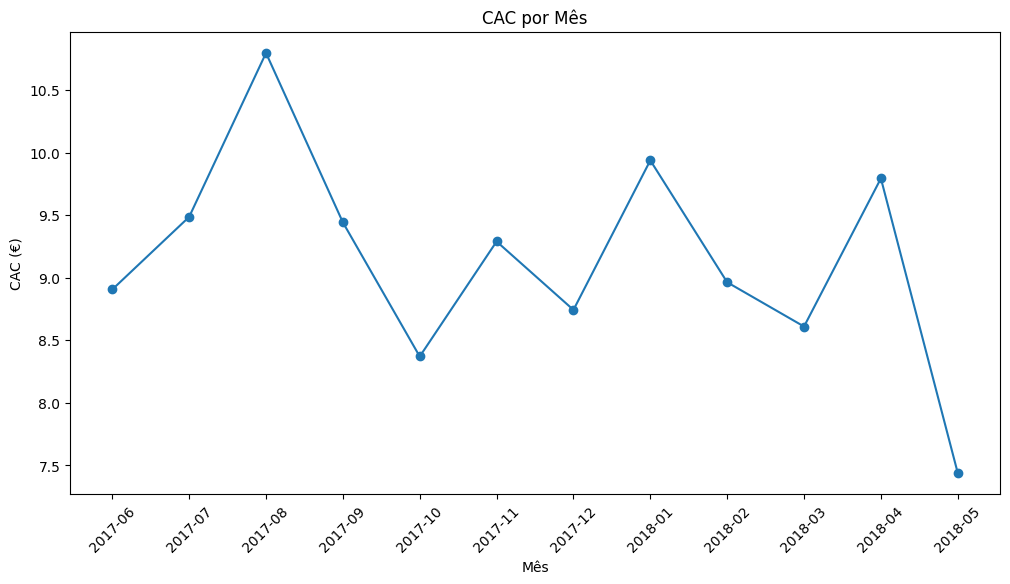

In [90]:
# Visualizando o CAC ao longo dos meses

plt.figure(figsize=(12, 6))

plt.plot(
    cac_data['cost_month'],
    cac_data['cac'],
    marker='o'
)

plt.title('CAC por Mês')
plt.xlabel('Mês')
plt.ylabel('CAC (€)')

plt.xticks(rotation=45)

plt.show()

#### Interpretação do CAC mensal

O CAC apresentou variações ao longo do período analisado, oscilando entre €7,44 e €10,80 por cliente.

O maior custo de aquisição ocorreu em agosto de 2017, com aproximadamente €10,80 por novo cliente. Já o menor CAC foi observado em maio de 2018, com aproximadamente €7,44.

Apesar das oscilações, não é observada uma tendência contínua de aumento ou redução do CAC. Na maior parte dos meses, o custo permaneceu em uma faixa relativamente próxima, entre aproximadamente €8 e €10 por cliente.

Essa análise permite avaliar a evolução do custo de aquisição, mas o CAC isoladamente não indica se a aquisição é economicamente eficiente. Para essa avaliação, é necessário compará-lo ao valor gerado pelos clientes, por meio da relação entre LTV e CAC.

#### Relação entre LTV e CAC

Para avaliar a eficiência econômica da aquisição de clientes, o LTV será comparado ao CAC de cada coorte.

A relação entre o LTV mensal e o CAC permite calcular o ROMI (Return on Marketing Investment), indicando quanto do custo de aquisição é recuperado pelo lucro bruto gerado pelos clientes em cada mês de vida.

O ROMI será posteriormente acumulado ao longo dos meses para identificar em que momento cada coorte recupera o investimento realizado para sua aquisição.

In [91]:
# Associando o CAC de cada coorte ao respectivo LTV mensal

romi_data = cohort_ltv.merge(
    cac_data[['cost_month', 'cac']],
    left_on='first_order_month',
    right_on='cost_month',
    how='left'
)

print(
    romi_data[
        ['first_order_month', 'cohort_month', 'ltv', 'cac']
    ].head(10)
)

  first_order_month  cohort_month       ltv       cac
0           2017-06             0  2.362207  8.905091
1           2017-06             1  0.242664  8.905091
2           2017-06             2  0.218819  8.905091
3           2017-06             3  0.477336  8.905091
4           2017-06             4  0.511265  8.905091
5           2017-06             5  0.367751  8.905091
6           2017-06             6  0.475220  8.905091
7           2017-06             7  0.290796  8.905091
8           2017-06             8  0.276607  8.905091
9           2017-06             9  0.302894  8.905091


#### Cálculo do ROMI por coorte

Para avaliar o retorno do investimento em marketing, será calculado o ROMI (Return on Marketing Investment) para cada coorte e mês de vida.

O ROMI será obtido pela divisão do LTV mensal pelo CAC da respectiva coorte.

Valores de ROMI inferiores a 1 indicam que, naquele mês, o lucro bruto gerado ainda não compensou o custo de aquisição. Valores iguais ou superiores a 1 indicam que o investimento já foi recuperado.

In [92]:
# Calculando o ROMI mensal

romi_data['romi'] = (
    romi_data['ltv'] /
    romi_data['cac']
)

print(
    romi_data[
        ['first_order_month', 'cohort_month', 'ltv', 'cac', 'romi']
    ].head(10)
)

  first_order_month  cohort_month       ltv       cac      romi
0           2017-06             0  2.362207  8.905091  0.265265
1           2017-06             1  0.242664  8.905091  0.027250
2           2017-06             2  0.218819  8.905091  0.024572
3           2017-06             3  0.477336  8.905091  0.053603
4           2017-06             4  0.511265  8.905091  0.057413
5           2017-06             5  0.367751  8.905091  0.041297
6           2017-06             6  0.475220  8.905091  0.053365
7           2017-06             7  0.290796  8.905091  0.032655
8           2017-06             8  0.276607  8.905091  0.031062
9           2017-06             9  0.302894  8.905091  0.034014


#### ROMI acumulado por coorte

Para identificar o momento em que o investimento de aquisição é recuperado, será calculado o ROMI acumulado ao longo dos meses de vida de cada coorte.

O valor acumulado será obtido pela soma dos ROMIs mensais. Quando o ROMI acumulado atingir ou ultrapassar 1, significa que o lucro bruto acumulado gerado pelos clientes da coorte corresponde ao custo de aquisição.

In [93]:
# Calculando o ROMI acumulado por coorte

romi_data = romi_data.sort_values(
    ['first_order_month', 'cohort_month']
)

romi_data['cumulative_romi'] = (
    romi_data
    .groupby('first_order_month')['romi']
    .cumsum()
)

print(
    romi_data[
        [
            'first_order_month',
            'cohort_month',
            'romi',
            'cumulative_romi'
        ]
    ].head(10)
)

  first_order_month  cohort_month      romi  cumulative_romi
0           2017-06             0  0.265265         0.265265
1           2017-06             1  0.027250         0.292515
2           2017-06             2  0.024572         0.317087
3           2017-06             3  0.053603         0.370690
4           2017-06             4  0.057413         0.428102
5           2017-06             5  0.041297         0.469399
6           2017-06             6  0.053365         0.522764
7           2017-06             7  0.032655         0.555419
8           2017-06             8  0.031062         0.586481
9           2017-06             9  0.034014         0.620494


#### Tabela de ROMI acumulado por coorte

Para comparar o retorno do investimento entre as diferentes coortes, será criada uma tabela com as coortes nas linhas e os meses de vida nas colunas.

Em seguida, o ROMI mensal será acumulado ao longo dos meses. Essa visualização permitirá identificar em que momento cada coorte atinge um ROMI acumulado igual ou superior a 1, indicando a recuperação do custo de aquisição.

In [94]:
# Criando a tabela de ROMI por coorte e mês de vida

romi_cohort_table = romi_data.pivot_table(
    index='first_order_month',
    columns='cohort_month',
    values='romi',
    aggfunc='mean'
)

# Calculando o ROMI acumulado ao longo dos meses

cumulative_romi_table = (
    romi_cohort_table
    .cumsum(axis=1)
)

print(cumulative_romi_table.round(2))

cohort_month         0     1     2     3     4     5     6     7     8     9   \
first_order_month                                                               
2017-06            0.27  0.29  0.32  0.37  0.43  0.47  0.52  0.56  0.59  0.62   
2017-07            0.32  0.33  0.37  0.39  0.40  0.40  0.41  0.42  0.43  0.43   
2017-08            0.24  0.27  0.29  0.31  0.33  0.34  0.35  0.37  0.38  0.39   
2017-09            0.30  0.36  0.39  0.60  0.62  0.65  0.69  0.70  0.71   NaN   
2017-10            0.30  0.33  0.34  0.35  0.36  0.37  0.37  0.38   NaN   NaN   
2017-11            0.28  0.30  0.31  0.33  0.34  0.34  0.34   NaN   NaN   NaN   
2017-12            0.27  0.29  0.34  0.40  0.42  0.44   NaN   NaN   NaN   NaN   
2018-01            0.21  0.22  0.24  0.25  0.25   NaN   NaN   NaN   NaN   NaN   
2018-02            0.23  0.25  0.25  0.26   NaN   NaN   NaN   NaN   NaN   NaN   
2018-03            0.28  0.30  0.32   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
2018-04            0.24  0.2

#### Interpretação do ROMI acumulado

Os resultados mostram que nenhuma das coortes atingiu um ROMI acumulado igual ou superior a 1 durante o período observado. Portanto, dentro da janela de análise disponível, nenhuma coorte recuperou integralmente o custo de aquisição por meio do lucro bruto gerado.

A coorte de setembro de 2017 apresentou o melhor desempenho observado, atingindo aproximadamente 0,71 no mês 8. A coorte de junho de 2017 alcançou aproximadamente 0,67 no mês 11.

Os resultados das coortes mais recentes devem ser interpretados com cautela, pois possuem menos meses de observação. Dessa forma, a ausência de recuperação do CAC dentro da janela analisada não permite concluir que essas coortes não recuperarão o investimento no longo prazo.

De modo geral, os resultados indicam que a recuperação do investimento em aquisição ocorre de forma lenta no período observado, sendo necessário acompanhar o comportamento das coortes por mais tempo para determinar se o CAC será integralmente recuperado.

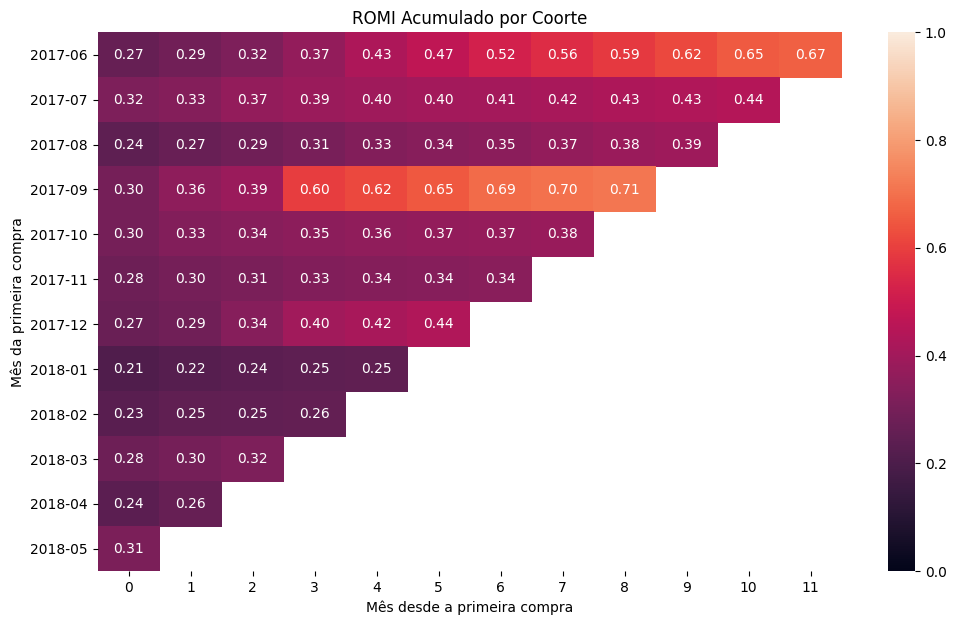

In [95]:
# Visualizando o ROMI acumulado por coorte

plt.figure(figsize=(12, 7))

sns.heatmap(
    cumulative_romi_table,
    annot=True,
    fmt='.2f',
    vmin=0,
    vmax=1
)

plt.title('ROMI Acumulado por Coorte')
plt.xlabel('Mês desde a primeira compra')
plt.ylabel('Mês da primeira compra')

plt.show()

#### Interpretação do ROMI acumulado

O ROMI acumulado permaneceu abaixo de 1,00 em todas as coortes durante o período observado, indicando que nenhuma delas recuperou integralmente o custo de aquisição por meio do lucro bruto gerado dentro da janela analisada.

A coorte de setembro de 2017 apresentou o melhor desempenho, atingindo aproximadamente 0,71 no oitavo mês após a primeira compra. Isso significa que, nesse ponto, o lucro bruto acumulado correspondia a aproximadamente 71% do CAC.

A coorte de junho de 2017 apresentou o segundo melhor desempenho entre as coortes com maior período de observação, alcançando aproximadamente 0,67 no décimo primeiro mês.

As coortes mais recentes apresentam valores menores de ROMI acumulado, mas possuem uma janela de observação mais curta. Portanto, não é possível concluir que não recuperarão o CAC no futuro.

De forma geral, os resultados indicam que a recuperação do investimento em aquisição é lenta no período analisado. Esse resultado sugere a necessidade de acompanhar a evolução das coortes por um período mais longo e avaliar estratégias para aumentar o valor gerado pelos clientes ou reduzir o custo de aquisição.

#### ROMI acumulado médio das coortes

Para obter uma visão geral do desempenho das coortes, será calculada a média do ROMI acumulado para cada mês de vida.

Essa análise permite avaliar o comportamento médio das coortes e verificar se, em média, o investimento em aquisição é recuperado dentro do período observado.

In [97]:
# Calculando o ROMI acumulado médio para cada mês de vida

average_cumulative_romi = cumulative_romi_table.mean(axis=0)

print(average_cumulative_romi.round(2))

cohort_month
0     0.27
1     0.29
2     0.32
3     0.36
4     0.39
5     0.43
6     0.45
7     0.48
8     0.53
9     0.48
10    0.55
11    0.67
dtype: float64


#### Interpretação do ROMI acumulado médio

O ROMI acumulado médio aumenta ao longo dos meses de vida das coortes, passando de 0,27 no mês 0 para 0,67 no mês 11.

Esse resultado indica que, em média, o lucro bruto acumulado representa uma parcela cada vez maior do custo de aquisição à medida que os clientes permanecem por mais tempo na plataforma.

Entretanto, os valores dos meses mais avançados devem ser interpretados com cautela, pois o número de coortes disponíveis diminui ao longo do tempo. As coortes mais recentes ainda não possuem meses de observação suficientes para contribuir para essas médias.

Mesmo no mês 11, o ROMI acumulado médio observado permanece abaixo de 1,00. Portanto, dentro da janela de observação disponível, o investimento em aquisição ainda não foi totalmente recuperado.

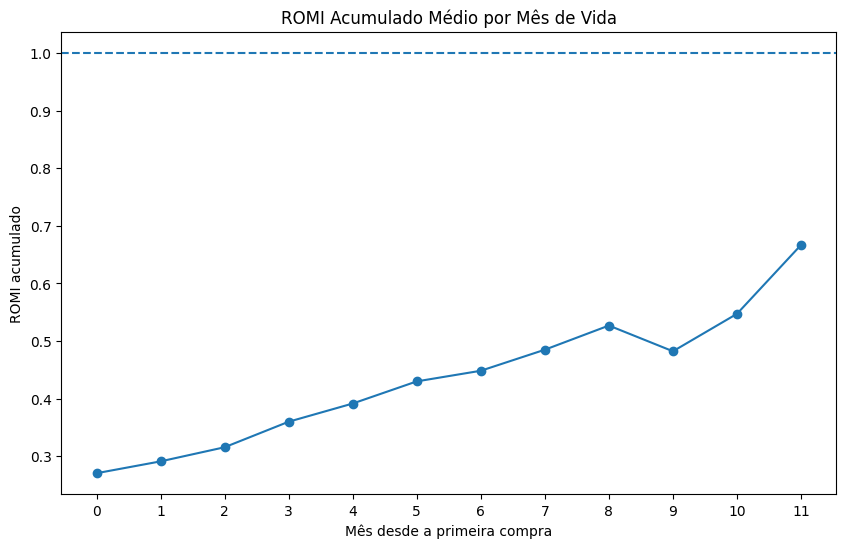

In [98]:
# Visualizando a evolução do ROMI acumulado médio

plt.figure(figsize=(10, 6))

plt.plot(
    average_cumulative_romi.index,
    average_cumulative_romi.values,
    marker='o'
)

plt.axhline(
    y=1,
    linestyle='--'
)

plt.title('ROMI Acumulado Médio por Mês de Vida')
plt.xlabel('Mês desde a primeira compra')
plt.ylabel('ROMI acumulado')

plt.xticks(average_cumulative_romi.index)

plt.show()

#### Interpretação do ROMI acumulado médio

O ROMI acumulado médio apresenta uma tendência geral de crescimento ao longo dos meses de vida das coortes, passando de 0,27 no primeiro mês para 0,67 no décimo primeiro mês.

Esse comportamento indica que os clientes continuam gerando lucro bruto ao longo do tempo, aumentando gradualmente a parcela do custo de aquisição que é recuperada.

Observa-se uma pequena redução entre os meses 8 e 9, quando o ROMI médio passa de 0,53 para 0,48. Essa variação deve ser interpretada com cautela, pois o número de coortes disponíveis diminui nos meses mais avançados e, consequentemente, a composição da média também se altera.

Mesmo após 11 meses, o ROMI acumulado médio permanece abaixo de 1,00. Portanto, dentro do período observado, o lucro bruto acumulado ainda não foi suficiente para recuperar integralmente o custo de aquisição.

Esse resultado reforça a importância de aumentar a retenção e o valor gerado pelos clientes ou reduzir o custo de aquisição, de modo a acelerar a recuperação do investimento em marketing.

## Conclusões da Economia Unitária

A análise de LTV, CAC e ROMI mostra que o negócio apresenta geração de valor ao longo do tempo, mas o ritmo de recuperação do investimento em aquisição é lento.

O CAC variou entre aproximadamente €7,44 e €10,80 por cliente entre junho de 2017 e maio de 2018. Apesar da variação mensal, não foi observada uma tendência contínua de aumento do custo de aquisição.

O ROMI acumulado permaneceu abaixo de 1,00 em todas as coortes durante a janela observada. A melhor coorte foi a de setembro de 2017, que atingiu aproximadamente 0,71 no oitavo mês. A coorte de junho de 2017 chegou a aproximadamente 0,67 no décimo primeiro mês.

Na média das coortes, o ROMI acumulado atingiu 0,67 no décimo primeiro mês. Portanto, dentro do período analisado, nenhuma coorte recuperou integralmente o investimento realizado em marketing.

As coortes mais recentes possuem períodos de observação menores e, por isso, seus resultados não podem ser comparados diretamente com os das coortes mais antigas sem considerar a diferença no tempo de vida.

O principal ponto de atenção identificado é, portanto, a velocidade de recuperação do CAC. O negócio precisa aumentar o valor gerado pelos clientes ao longo do tempo e/ou reduzir o custo de aquisição para melhorar a economia unitária.

## Resumo dos Principais Resultados

| Área | Indicador | Resultado principal | Interpretação |
|---|---|---|---|
| Retenção | Retenção por coorte | Forte queda após o primeiro mês | A maioria dos usuários não permanece ativa nos meses seguintes |
| Conversão | Tempo até a primeira compra | Forte concentração das compras nos primeiros dias | Muitos usuários que convertem tomam a decisão de compra rapidamente |
| Comportamento | Número de pedidos | Mediana = 1 pedido por cliente | A recompra é limitada para a maior parte dos clientes |
| Receita | Receita por cliente | Distribuição fortemente assimétrica | Uma parcela menor de clientes concentra valores de receita mais elevados |
| Aquisição | CAC | €7,44–€10,80 | O custo de aquisição apresentou variação, mas permaneceu relativamente estável |
| Valor do cliente | LTV | Crescimento ao longo dos meses | Clientes continuam gerando valor após a primeira compra |
| Rentabilidade | ROMI acumulado | Máximo observado ≈ 0,71 | Nenhuma coorte recuperou integralmente o CAC dentro da janela analisada |
| Retorno | ROMI médio acumulado | 0,27 → 0,67 entre os meses 0 e 11 | A recuperação do investimento ocorre lentamente no período observado |

## Conclusões da Análise

A análise dos dados de usuários, sessões e pedidos permitiu identificar os principais pontos do comportamento dos clientes e da eficiência da aquisição.

### Retenção

A análise de coortes mostrou uma queda acentuada na retenção após o primeiro mês. A maior parte dos usuários não retorna nos meses seguintes, indicando uma oportunidade de melhoria na fidelização e no engajamento dos clientes.

### Conversão

A distribuição do tempo até a primeira compra mostrou uma forte concentração das conversões próximas à primeira visita. Ao mesmo tempo, existe uma cauda longa de usuários que levam períodos muito maiores para realizar a primeira compra.

### Comportamento de compra

A mediana de pedidos por cliente é igual a 1, indicando que pelo menos metade dos clientes realizou apenas um pedido durante o período analisado.

A distribuição da receita também apresenta forte assimetria: a maior parte dos clientes gera valores relativamente baixos, enquanto uma parcela menor apresenta receitas muito superiores.

### Economia unitária

O CAC variou entre aproximadamente €7,44 e €10,80 por cliente ao longo do período analisado.

O ROMI acumulado permaneceu abaixo de 1,00 em todas as coortes dentro da janela de observação. A melhor coorte observada foi a de setembro de 2017, que atingiu aproximadamente 0,71 no oitavo mês.

Na média das coortes, o ROMI acumulado chegou a aproximadamente 0,67 no décimo primeiro mês. Portanto, não foi observada recuperação integral do CAC dentro do período analisado.

### Síntese

Os resultados indicam que o principal desafio identificado não está apenas na aquisição de novos clientes, mas na capacidade de transformar esses clientes em compradores recorrentes e aumentar o valor gerado ao longo do tempo.

A combinação de baixa retenção, predominância de clientes com apenas um pedido e recuperação lenta do CAC indica que estratégias de retenção, recompra e aumento do valor do cliente devem ser consideradas como prioridades para melhorar a economia unitária.

## Recomendações Estratégicas

Com base nos resultados obtidos, as recomendações são organizadas segundo seu potencial impacto sobre a economia unitária do negócio. O foco deve estar não apenas na aquisição de novos usuários, mas na capacidade de transformar aquisição em clientes recorrentes e rentáveis.

### 1. Priorizar estratégias de retenção e recompra

A queda acentuada da retenção após o primeiro mês e a mediana de apenas um pedido por cliente indicam que o principal desafio está na continuidade do relacionamento após a aquisição.

Recomenda-se desenvolver uma estratégia de ciclo de vida do cliente, diferenciando usuários de acordo com seu estágio de relacionamento com a plataforma. Ações de onboarding, comunicação pós-compra, recomendações personalizadas e campanhas de reativação podem ser testadas para aumentar a frequência de compra.

A prioridade deve ser dada aos segmentos com maior potencial de valor, utilizando comportamento de navegação e histórico de compras para personalizar as ações.

**Hipótese:** aumentar a frequência de compra e a retenção elevará o LTV e reduzirá o tempo necessário para recuperar o CAC.

**KPIs:** retenção por coorte, taxa de recompra, pedidos por cliente, receita por cliente e LTV.

### 2. Otimizar a aquisição com base no valor gerado pelos clientes

O CAC apresentou variação entre €7,44 e €10,80, enquanto nenhuma das coortes recuperou integralmente o CAC dentro da janela observada.

Por isso, a otimização da aquisição não deve considerar apenas o volume ou o custo de novos clientes. Recomenda-se avaliar a performance das diferentes fontes de aquisição considerando conjuntamente CAC, retenção, receita e LTV.

Os investimentos devem ser gradualmente direcionados para as fontes que apresentem melhor capacidade de gerar clientes recorrentes e maior valor ao longo do ciclo de vida.

**Hipótese:** a redistribuição do investimento para fontes com maior LTV/CAC poderá melhorar o ROMI sem depender exclusivamente da redução do investimento total em marketing.

**KPIs:** CAC por fonte, LTV por fonte, LTV/CAC, ROMI e retenção por canal.

### 3. Desenvolver programas de aumento do valor do cliente

A forte assimetria observada na receita indica que existe uma parcela de clientes que gera valores significativamente superiores aos demais.

Recomenda-se investigar as características comportamentais desses clientes e identificar padrões associados a maior receita e maior frequência de compra. Esses padrões podem ser utilizados para desenvolver estratégias de cross-selling, up-selling e personalização de ofertas.

**Hipótese:** replicar comportamentos associados aos clientes de maior valor pode aumentar a receita média e o LTV sem exigir proporcionalmente novos investimentos em aquisição.

**KPIs:** receita por cliente, frequência de pedidos, ticket médio, LTV e participação dos clientes de alto valor na receita.

### 4. Reduzir fricções no processo de conversão

A concentração das primeiras compras próxima à primeira visita indica que uma parcela relevante dos usuários toma sua decisão rapidamente, enquanto existe também uma cauda de usuários que demora significativamente mais para converter.

Recomenda-se investigar as etapas da jornada entre aquisição, primeira visita e compra para identificar possíveis pontos de fricção. Testes A/B podem ser utilizados para avaliar melhorias na experiência, comunicação de benefícios, ofertas de primeira compra e remarketing.

**Hipótese:** reduzir as barreiras à primeira compra poderá aumentar a taxa de conversão sem necessariamente aumentar o investimento em aquisição.

**KPIs:** taxa de conversão, tempo até a primeira compra, custo por cliente convertido e taxa de abandono.

### Consideração final

Os resultados mostram que o principal desafio do negócio não está apenas em atrair novos usuários, mas em transformar a aquisição em valor sustentável ao longo do ciclo de vida do cliente.

Nesse contexto, a estratégia de marketing deve buscar um equilíbrio entre aquisição, conversão, retenção e monetização. O aumento da frequência de compra e do LTV, combinado à otimização do CAC, tende a ser fundamental para acelerar a recuperação do investimento em marketing e melhorar a economia unitária.

As recomendações apresentadas devem ser tratadas como hipóteses de negócio a serem testadas e acompanhadas por indicadores de desempenho. Dessa forma, a análise de dados deixa de ser apenas uma avaliação do desempenho passado e passa a apoiar decisões de marketing orientadas à criação de valor e ao crescimento sustentável.